# Financial Vulnerability in Canadian Households
**A machine-learning analysis of Statistics Canada's Survey of Financial Security (2023)**

Mohammad Bhatti, BSc (Hons)

## Abstract
About **4%** of Canadian families in Statistics Canada's 2023 Survey of Financial Security report skipping a payment because of financial hardship. This project asks two questions about those families: what separates them from everyone else, and can they be predicted?

Two hypothesis tests opened the first question. A t-test confirmed a real wealth gap - vulnerable families hold significantly less net worth than everyone else - and a chi-square test found that hardship varies with education, though as an arch rather than a straight line, peaking in the middle levels. The models then explained the *why*: what separates vulnerable families is the balance sheet. Every kind of debt raises the risk, **credit-card debt most steeply**, while net worth, income, and age protect so strongly that demographics barely matter once finances are known. The education arch turned out to be **mostly age and wealth in disguise** - something the two-column chi-square could not untangle on its own.

And yes, the families can be predicted, to a point: a tuned random forest, with its decision threshold lowered to fit a rare-class problem, catches **4 out of 5 vulnerable families (AUC 0.83)** - a wide-net screening tool rather than a precision instrument. The short version: vulnerability is not about who a family is, it is about what they owe versus what they have to fall back on.

## Overview
This project is about financially vulnerable Canadian families, and it asks two questions: **what separates vulnerable families from everyone else, and can we predict which families are vulnerable?** The backdrop is Canada's 2025-26 technical recession (two consecutive quarterly GDP declines, on an annualized basis). The data is Statistics Canada's 2023 Survey of Financial Security (SFS), a survey of the assets, debts, and net worth of Canadian families.

**How "vulnerable" is defined:** a family that skipped a payment because of financial difficulty (`missed_pay_hardship` = 1, about 4% of families). It's the survey's own recorded distress signal, and payment behavior is the same standard banks and the Bank of Canada use to measure household financial trouble. The full reasoning is in [Section 1.9.7](#s1-9-7). With the definition set, the two questions split cleanly. **Explaining** is Section 2's job, with two tests: does the hardship group really hold less net worth (the wealth gap), and does the hardship rate depend on education (the education pattern)? **Predicting** is Section 3's job: a classifier that flags vulnerable households from their finances and demographics.

## Objectives
1. **Clean & prepare** the SFS microdata (handle the survey's coded values, missing data, and valid skips).
2. **Explore & test** which factors separate financially vulnerable families from the rest.
3. **Model & evaluate** a classifier that predicts vulnerable households.

## Data
- **Source:** Statistics Canada, Survey of Financial Security 2023, Public Use Microdata File (PUMF). [Documentation & download](https://www150.statcan.gc.ca/n1/en/catalogue/13M0006X)
- **Unit of analysis:** one row per economic family (16,241 families; 23 selected variables).
- **Scope note:** the SFS covers housed families in the ten provinces and excludes people who are homeless, institutionalised, or living on reserves, so it understates the most extreme vulnerability (expanded on in the limitations).

## Tools
Python - pandas & numpy for the data work, matplotlib & seaborn for visualisation, scipy & statsmodels for the statistical tests and weighted statistics, and scikit-learn for the modelling.

## Contents
**[Data dictionary (quick reference)](#dict)**

**1. [Cleaning, preparing and visualizing the data](#s1)**
- [1.1 Setup](#s1-1)
- [1.2 Load the data](#s1-2)
- [1.3 Select and rename the columns](#s1-3)
- [1.4 First look at the data](#s1-4)
- [1.5 Data-quality checks](#s1-5)
  - [1.5.1 Hidden missing values, the codebook trap](#s1-5-1)
- [1.6 Cleaning valid skips (code 6)](#s1-6)
  - [1.6.1 missed_pay_mortgage](#s1-6-1)
  - [1.6.2 missed_pay_hardship](#s1-6-2)
  - [1.6.3 retired](#s1-6-3)
  - [1.6.4 Why I binarized these flags](#s1-6-4)
- [1.7 Cleaning not-stated values (code 9)](#s1-7)
  - [1.7.1 education (weighted median)](#s1-7-1)
  - [1.7.2 retired (weighted mode)](#s1-7-2)
  - [1.7.3 visible_minority (kept as "unknown")](#s1-7-3)
- [1.8 The income_market sentinel](#s1-8)
- [1.9 Early data analysis](#s1-9)
  - [1.9.1 The dollar columns - net worth, raw vs log](#s1-9-1)
  - [1.9.2 The dollar columns - all 11 distributions](#s1-9-2)
  - [1.9.3 Correlations between the dollar columns](#s1-9-3)
  - [1.9.4 The categorical columns - counts](#s1-9-4)
  - [1.9.5 Net worth across the categories](#s1-9-5)
  - [1.9.6 Income after tax across the categories](#s1-9-6)
  - [1.9.7 Wrapping up - from the graphs to the hypotheses](#s1-9-7)

**2. [Hypothesis testing](#s2)**
- [2.1 Test 1 - the wealth gap (Welch's t-test)](#s2-1)
- [2.2 Test 2 - the education pattern (chi-square)](#s2-2)

**3. [Machine-learning model](#s3)**
- [3.1 New feature - debt-to-income](#s3-1)
  - [3.1.1 The nulls](#s3-1-1)
  - [3.1.2 The infinities](#s3-1-2)
  - [3.1.3 The negatives](#s3-1-3)
- [3.2 The target and the features (y and X)](#s3-2)
  - [3.2.1 The target (y)](#s3-2-1)
  - [3.2.2 The features (X)](#s3-2-2)
- [3.3 Preprocessing - encoding and scaling](#s3-3)
  - [3.3.1 Sorting the columns into the two branches](#s3-3-1)
  - [3.3.2 Building the column transformer](#s3-3-2)
- [3.4 Train/test split - then the column transformer fits](#s3-4)
  - [3.4.1 The split - stratified and reproducible](#s3-4-1)
  - [3.4.2 Fitting on the training set](#s3-4-2)
  - [3.4.3 Recovering the column names](#s3-4-3)
- [3.5 Logistic regression - the baseline](#s3-5)
  - [3.5.1 Building the baseline](#s3-5-1)
  - [3.5.2 Hyperparameter tuning (grid search + cross-validation)](#s3-5-2)
- [3.6 Random forest - the ensemble](#s3-6)
  - [3.6.1 Building the forest](#s3-6-1)
  - [3.6.2 Hyperparameter tuning (the forest's grid)](#s3-6-2)
- [3.7 Reading the models](#s3-7)
  - [3.7.1 Scoring on the test set](#s3-7-1)
  - [3.7.2 The decision threshold](#s3-7-2)
  - [3.7.3 What drives vulnerability](#s3-7-3)
  - [3.7.4 Limitations](#s3-7-4)

**[Epilogue: testing the Bank of Canada's debt benchmark](#epilogue)**
- [E.1 Flagging the highly-indebted families](#ep-1)
- [E.2 Does the benchmark catch who actually breaks?](#ep-2)
- [E.3 How Canada-wide is this?](#ep-3)

**[References](#references)**

**[Appendix: full data dictionary](#appendix)**

---

<a id="dict"></a>
## Data dictionary (quick reference)
The 23 selected columns are below (renamed from their StatCan codes). Many are stored as **numeric codes**, not literal values. Each column's code meanings are explained inline as it's cleaned, and the **full code-by-code dictionary is in the [Appendix](#appendix) at the bottom**. (Dollar amounts are in Canadian dollars, "CAD".)

| Column | What it is |
|---|---|
| `family_id` | Unique family identifier _(not a predictor)_ |
| `weight` | Survey weight, families this row represents _(not a predictor)_ |
| `income_after_tax` | After-tax income (CAD) |
| `income_market` | Market income (CAD) |
| `income_main_source` | Main source of family income _(coded)_ |
| `income_expected_change` | Expected income change over next 2 yrs _(coded)_ |
| `assets_total` | Total assets incl. employer pensions (CAD) |
| `net_worth` | Net worth = assets minus debts (CAD) |
| `debt_total` | Total debt (CAD) |
| `debt_mortgage` | Mortgage on principal residence (CAD) |
| `debt_credit_card` | Credit-card & installment debt (CAD) |
| `debt_student_loan` | Student-loan debt (CAD) |
| `debt_line_of_credit` | Line-of-credit debt (CAD) |
| `debt_vehicle` | Vehicle debt (CAD) |
| `debt_other` | Other debt (CAD) |
| `missed_pay_hardship` | Skipped a non-mortgage payment due to financial difficulty _(coded)_ |
| `missed_pay_nonmortgage` | Skipped a non-mortgage payment, any reason _(coded)_ |
| `missed_pay_mortgage` | Skipped a mortgage payment _(coded)_ |
| `age_group` | Age of major income earner, grouped _(coded)_ |
| `education` | Highest education of major income earner _(coded)_ |
| `gender` | Gender of major income earner _(coded)_ |
| `retired` | Major income earner ever retired _(coded)_ |
| `visible_minority` | Visible-minority status _(coded)_ |

_Two more columns get engineered on top of these 23: `debt_to_income` = `debt_total` / `income_after_tax`, built and cleaned in [3.1](#s3-1), and the Epilogue's `BOC_DTI` flag (1 = debt at or above 3.5 times income), built in [E.1](#ep-1)._

---

<a id="s1"></a>
# Section 1 - Cleaning, preparing and visualizing the data
Loading the raw SFS file, selecting and renaming the columns we need, checking data quality, and handling the survey's coded values (valid skips and missing data), then taking a first exploratory look at the cleaned data.

<a id="s1-1"></a>
## 1.1 Setup
Let's load the libraries we need to get started.

In [1]:
import numpy as np                 # numerical arrays and math
import pandas as pd                # dataframes for tabular data
import os                          # file-path helpers
import warnings                    # control warning messages
import matplotlib.pyplot as plt    # base plotting
import seaborn as sns              # statistical visualisations
from statsmodels.stats.weightstats import DescrStatsW   # weighted statistics (used for the weighted median)
import scipy.stats as stats        # statistical tests (used for the Welch t-test)
from scipy.stats import chi2_contingency               # chi-square test of independence
from sklearn.linear_model import LogisticRegression    # baseline model (interpretable, gives odds ratios)
from sklearn.ensemble import RandomForestClassifier    # tree-ensemble model (stronger prediction)
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix   # imbalance-honest scoring
from sklearn.preprocessing import MinMaxScaler          # scales numeric features to a 0-1 range 
from sklearn.preprocessing import OneHotEncoder         # turns category columns into yes/no columns 
from sklearn.compose import ColumnTransformer           # routes each column to the right preprocessing step 
from sklearn.model_selection import train_test_split   # splits X and y into train and test sets (used from 3.4 on)
from sklearn.model_selection import GridSearchCV   # cross-validated grid search over hyperparameters (used in 3.5.2 and 3.6)
warnings.filterwarnings("ignore")  # hide warnings for a cleaner notebook
sns.set_theme(style="darkgrid", palette="deep")   # one shared style (font, grid, colors) for every plot in the notebook

<a id="s1-2"></a>
## 1.2 Load the data
The data can be accessed from the [Statistics Canada SFS 2023 page](https://www150.statcan.gc.ca/n1/en/catalogue/13M0006X). It ships as a CSV of 16,241 families and 102 columns.

In [2]:
df = pd.read_csv("sfs2023_efam_pumf.csv")   # load the SFS 2023 PUMF (one row per economic family)
df                                          # preview the raw dataframe (16,241 rows x 102 columns)

,PEFAMID,PWEIGHT,PAGEMIEG,PAS1MRAG,PAS1MRG1,PAS1MRG2,PASR1MFA,PASR1MR,PASRBUYG,PASRCNMG,...,PWDSLOAN,PWDSTCRD,PWDSTLOC,PWDSTODB,PWDSTOMR,PWDSTVHN,PWDTOTAL,PWNETWPG,PWNETWPT,VERDATE
0,1,537.4531,6,6,6,6,99999996,6,3,6,...,0,0,0,0,0,30000,30000,3713000,3713000,14/05/2025
1,2,83.3934,7,6,6,6,99999996,6,7,1,...,0,0,145000,0,82500,0,227500,1740900,1750900,14/05/2025
2,3,1130.0899,5,6,6,6,99999996,6,4,6,...,0,0,40000,0,0,0,40000,3672500,3667500,14/05/2025
3,4,606.9363,6,6,6,6,99999996,2,7,6,...,0,18500,10000,0,0,18500,227000,2809050,2859050,14/05/2025
4,5,1226.3811,4,6,6,6,99999996,6,96,6,...,0,0,0,0,0,0,0,471900,441900,14/05/2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16236,16237,658.7783,4,6,6,6,99999996,6,96,6,...,0,0,0,0,0,0,0,96850,96850,14/05/2025
16237,16238,21.9636,6,6,6,6,6250,2,6,6,...,0,0,0,0,0,0,28000,1989000,1981500,14/05/2025
16238,16239,2373.9165,2,6,6,6,99999996,2,6,6,...,30000,0,850,0,0,33000,146350,240100,239600,14/05/2025
16239,16240,1331.8587,3,6,6,6,99999996,6,96,6,...,2500,450,0,50,0,0,3000,23750,23750,14/05/2025


<a id="s1-3"></a>
## 1.3 Select and rename the columns
The data comes with a codebook that explains what each of the columns are. I'm only going to rename the columns I deem important for our work, and filter the rest out.

Quick note on why these 23: out of the 102 columns, I kept the ones that actually speak to a family's money situation - income, assets, debts, the payment-stress flags, and a few basic demographics. Those are the pieces most likely to help predict vulnerability and answer the questions we'll test later; the rest I left out to keep things focused.

In [3]:
# the data comes with a codebook that explains what each of the columns are.
# I'm going to rename only the columns I deem important for our work and filter them out.

rename_map = {
    # identifiers & weight
    "PEFAMID":  "family_id",
    "PWEIGHT":  "weight",
    # income
    "PEFATINC": "income_after_tax",
    "PEFMTINC": "income_market",
    "PEFMJSIF": "income_main_source",
    "PATTSTIN": "income_expected_change",
    # assets & net worth
    "PWATOTPG": "assets_total",
    "PWNETWPG": "net_worth",
    # debts
    "PWDTOTAL": "debt_total",
    "PWDPRMOR": "debt_mortgage",
    "PWDSTCRD": "debt_credit_card",
    "PWDSLOAN": "debt_student_loan",
    "PWDSTLOC": "debt_line_of_credit",
    "PWDSTVHN": "debt_vehicle",
    "PWDSTODB": "debt_other",
    # financial stress flags
    "PATTDIF":  "missed_pay_hardship",
    "PATTSKP":  "missed_pay_nonmortgage",
    "PASRSKP":  "missed_pay_mortgage",
    # demographics
    "PAGEMIEG": "age_group",
    "PEDUCMIE": "education",
    "PGDRMIE":  "gender",
    "PRETIRME": "retired",
    "PVMFMIE":  "visible_minority",
}

df = df[list(rename_map)].rename(columns = rename_map)   # keep only the 23 chosen columns, with readable names
df                                                        # preview the trimmed & renamed dataframe

,family_id,weight,income_after_tax,income_market,income_main_source,income_expected_change,assets_total,net_worth,debt_total,debt_mortgage,...,debt_vehicle,debt_other,missed_pay_hardship,missed_pay_nonmortgage,missed_pay_mortgage,age_group,education,gender,retired,visible_minority
0,1,537.4531,115525,125000,6,1,3743000,3713000,30000,0,...,30000,0,6,2,6,6,4,2,1,2
1,2,83.3934,121300,99999999,6,3,1968400,1740900,227500,0,...,0,0,6,2,6,7,9,2,1,2
2,3,1130.0899,19175,31000,7,3,3712500,3672500,40000,0,...,0,0,6,2,6,5,4,1,1,2
3,4,606.9363,147425,140000,2,3,3036050,2809050,227000,180000,...,18500,0,6,2,2,6,4,1,1,2
4,5,1226.3811,56750,65000,2,3,471900,471900,0,0,...,0,0,6,2,6,4,3,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16236,16237,658.7783,47175,52500,2,1,96850,96850,0,0,...,0,0,6,2,6,4,4,2,2,2
16237,16238,21.9636,121925,120000,2,3,2017000,1989000,28000,28000,...,0,0,6,2,2,6,2,1,2,2
16238,16239,2373.9165,124425,90000,2,1,386450,240100,146350,82500,...,33000,0,6,2,2,2,4,2,6,2
16239,16240,1331.8587,67625,75000,2,2,26750,23750,3000,0,...,0,50,2,1,6,3,3,1,6,1


<a id="s1-4"></a>
## 1.4 First look at the data
Running some simple checks to get a better sense of the data: its shape, columns, and data types.

_Note: I'll keep the dtypes as they are for now. (Bear in mind `describe()` on the coded columns, like `gender`, produces meaningless averages, since those numbers are category labels, not quantities.)_

In [4]:
print(df.shape)     # (rows, columns) -> (16241, 23)
print(df.info())    # column names, non-null counts, and data types

(16241, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16241 entries, 0 to 16240
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   family_id               16241 non-null  int64  
 1   weight                  16241 non-null  float64
 2   income_after_tax        16241 non-null  int64  
 3   income_market           16241 non-null  int64  
 4   income_main_source      16241 non-null  int64  
 5   income_expected_change  16241 non-null  int64  
 6   assets_total            16241 non-null  int64  
 7   net_worth               16241 non-null  int64  
 8   debt_total              16241 non-null  int64  
 9   debt_mortgage           16241 non-null  int64  
 10  debt_credit_card        16241 non-null  int64  
 11  debt_student_loan       16241 non-null  int64  
 12  debt_line_of_credit     16241 non-null  int64  
 13  debt_vehicle            16241 non-null  int64  
 14  debt_other              16

In [5]:
df.describe()   # summary statistics for every numeric column

,family_id,weight,income_after_tax,income_market,income_main_source,income_expected_change,assets_total,net_worth,debt_total,debt_mortgage,...,debt_vehicle,debt_other,missed_pay_hardship,missed_pay_nonmortgage,missed_pay_mortgage,age_group,education,gender,retired,visible_minority
count,16241.000000,16241.000000,1.624100e+04,1.624100e+04,16241.000000,16241.000000,1.624100e+04,1.624100e+04,1.624100e+04,1.624100e+04,...,16241.000000,1.624100e+04,16241.000000,16241.000000,16241.000000,16241.000000,16241.000000,16241.000000,16241.000000,16241.000000
mean,8121.000000,1037.554461,1.034073e+05,4.971678e+06,3.311003,2.296041,1.659429e+06,1.504155e+06,1.552743e+05,8.864644e+04,...,7284.790653,2.959426e+03,5.738932,1.945077,4.551875,4.721384,3.313035,1.427498,2.761468,2.496213
std,4688.517196,1157.150900,9.798081e+04,2.148876e+07,1.613828,0.862057,2.172580e+06,2.060683e+06,3.990438e+05,1.829757e+05,...,18135.572118,2.946575e+04,1.087691,0.227836,1.935737,1.494288,1.447959,0.494731,2.164366,2.108013
min,1.000000,10.000000,-2.701225e+06,-2.700000e+04,1.000000,1.000000,-5.125000e+04,-2.388150e+06,0.000000e+00,0.000000e+00,...,0.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4061.000000,305.162200,5.005000e+04,4.000000e+04,2.000000,1.000000,3.930000e+05,2.907500e+05,0.000000e+00,0.000000e+00,...,0.000000,0.000000e+00,6.000000,2.000000,2.000000,4.000000,2.000000,1.000000,1.000000,2.000000
50%,8121.000000,644.428200,8.482500e+04,8.750000e+04,2.000000,3.000000,1.057000e+06,9.047050e+05,2.000000e+04,0.000000e+00,...,0.000000,0.000000e+00,6.000000,2.000000,6.000000,5.000000,3.000000,1.000000,2.000000,2.000000
75%,12181.000000,1408.677900,1.334500e+05,1.650000e+05,4.000000,3.000000,2.125500e+06,1.947005e+06,1.854500e+05,1.150000e+05,...,3100.000000,0.000000e+00,6.000000,2.000000,6.000000,6.000000,4.000000,2.000000,6.000000,2.000000
max,16241.000000,18834.084500,1.979625e+06,1.000000e+08,7.000000,3.000000,3.782700e+07,3.777975e+07,1.172000e+07,2.400000e+06,...,260000.000000,1.100000e+06,6.000000,2.000000,6.000000,7.000000,9.000000,2.000000,9.000000,9.000000


<a id="s1-5"></a>
## 1.5 Data-quality checks: missing values and duplicates
First, check for blank/`NaN` values, then check for duplicate rows.

In [6]:
df.isnull().sum()   # count blank / NaN values in each column

family_id                 0
weight                    0
income_after_tax          0
income_market             0
income_main_source        0
income_expected_change    0
assets_total              0
net_worth                 0
debt_total                0
debt_mortgage             0
debt_credit_card          0
debt_student_loan         0
debt_line_of_credit       0
debt_vehicle              0
debt_other                0
missed_pay_hardship       0
missed_pay_nonmortgage    0
missed_pay_mortgage       0
age_group                 0
education                 0
gender                    0
retired                   0
visible_minority          0
dtype: int64

In [7]:
print('# of duplicated rows:',int(df.duplicated().sum()))   # how many fully-identical rows exist
df[df.duplicated()]                                         # show any duplicate rows (expecting none)

# of duplicated rows: 0


,family_id,weight,income_after_tax,income_market,income_main_source,income_expected_change,assets_total,net_worth,debt_total,debt_mortgage,...,debt_vehicle,debt_other,missed_pay_hardship,missed_pay_nonmortgage,missed_pay_mortgage,age_group,education,gender,retired,visible_minority


<a id="s1-5-1"></a>
### 1.5.1 Hidden missing values, the codebook trap
There may not appear to be any null/empty values, but if you refer to the codebook provided with the dataset, you'll see a few special codes worth knowing:

- **Code `6`** - the question _did not apply_ (a "valid skip"). This is **not** missing data.
- **Code `9`** - the answer was _not stated_ (a genuinely absent answer).
- For `income_market`, the maximum value is **99,999,999**, a "not stated" code (not a real income), so we can treat it as missing.

I'll clean **by code**: first the valid-skip `6`s, then the not-stated `9`s, then the `income_market` sentinel, so the treatment stays consistent.

In [8]:
# count how many 6's appear in each column
df[df == 6].count()

family_id                     1
weight                        0
income_after_tax              0
income_market                 0
income_main_source         2771
income_expected_change        0
assets_total                  0
net_worth                     0
debt_total                    0
debt_mortgage                 0
debt_credit_card              0
debt_student_loan             0
debt_line_of_credit           0
debt_vehicle                  0
debt_other                    0
missed_pay_hardship       15349
missed_pay_nonmortgage        0
missed_pay_mortgage       10403
age_group                  4977
education                     0
gender                        0
retired                    4039
visible_minority              0
dtype: int64

**Note:** the `6` means something different in each column. For example, `6` is just a family ID number in `family_id`, and it means "retirement pension" in `income_main_source`. Code `6` is only treated as a valid skip in the columns where it _solely_ means "the question did not apply" (as per the codebook).

I don't want to drop the rows that contain a `6`, because they still hold valuable information. Instead I refine the affected columns. The three where `6` is a genuine valid skip are `missed_pay_mortgage`, `missed_pay_hardship`, and `retired`.

<a id="s1-6"></a>
## 1.6 Cleaning valid skips (code `6`)
<a id="s1-6-1"></a>
### 1.6.1 `missed_pay_mortgage` (valid-skip code `6`)
This column asks two things at once: (1) do you have a mortgage, and (2) did you skip a payment. Code `6` = "valid skip" = no mortgage (10,403 families).

**First idea (explored, not used):** split it into two columns, `has_mortgage` (yes/no) and `skipped_mortgage_payment` (yes/no), then drop the original. For the no-mortgage families I'd set `skipped_mortgage_payment` = No, since you can't skip a mortgage payment you don't owe (a renter is effectively paying the landlord's mortgage, if the landlord even has one).

> **Limitation worth flagging:** the SFS excludes people living full-time in institutions, on reserves, in senior residences, military camps, and the homeless, so everyone in this data has a dwelling and is either an owner or a renter, never unhoused. The most vulnerable are outside the survey frame.

In [9]:
# check whether a "has_mortgage" column would be new information, or just duplicate debt_mortgage.
# left side = has a mortgage per the skip question; right side = has mortgage debt. compare row by row, then average the matches.
(df["missed_pay_mortgage"].isin([1,2]) == (df["debt_mortgage"]> 0)).mean()   # ~0.9996 -> the two agree 99.96% of the time

np.float64(0.9996305646204051)

**Why I changed it:** I tested whether `has_mortgage` would actually add new information. It wouldn't. `has_mortgage` is **99.96% identical** to (`debt_mortgage > 0`); only 6 of 16,241 rows differ. So a separate `has_mortgage` column would just duplicate a signal the dataset already holds in `debt_mortgage`.

**Final approach:** drop the redundant-column idea. Recode the valid-skip `6` to `2` ("No"), which now includes people who don't have a mortgage, whether they paid it off or never had one, producing one clean binary flag: `missed_pay_mortgage` (`1` = skipped, `2` = did not skip / no mortgage). Let `debt_mortgage` carry the "has a mortgage" signal. This keeps all 16,241 rows, loses no information, and avoids a redundant feature.

In [10]:
df["missed_pay_mortgage"] = df["missed_pay_mortgage"].replace(6,2)   # fold the valid-skip 6 into "No" (2)
print('Unique Values are: ',df.missed_pay_mortgage.unique())         # confirm only [1, 2] remain
print(df["missed_pay_mortgage"].value_counts())                      # confirm counts moved correctly: 2 -> 16074, 1 -> 167

Unique Values are:  [2 1]
missed_pay_mortgage
2    16074
1      167
Name: count, dtype: int64


<a id="s1-6-2"></a>
### 1.6.2 `missed_pay_hardship` (valid-skip code `6`)
`missed_pay_hardship` is a **follow-up** to `missed_pay_nonmortgage`. It was only asked of families who had already said they skipped a non-mortgage payment. So its `6` ("valid skip", 15,349 families) is exactly the group who _didn't_ skip a payment at all: you can't have skipped one "due to hardship" if you didn't skip one to begin with.

_Side note: `missed_pay_hardship` is one of the strongest single indicators of a family being financially stressed and potentially vulnerable, worth remembering when we define the target._

**Same logic as the mortgage column:** recode the valid-skip `6` to `2` ("No"), giving a clean binary, `1` = skipped a payment due to hardship, `2` = did not (for any reason). The "did they skip at all?" gate is already carried by `missed_pay_nonmortgage`, so nothing is lost.

In [11]:
# missed_pay_hardship is a follow-up to missed_pay_nonmortgage; its 6 = "didn't skip a payment" (question didn't apply).
df["missed_pay_hardship"] = df["missed_pay_hardship"].replace(6,2)   # fold the valid-skip 6 into "No" (2)
df["missed_pay_hardship"].value_counts()                             # confirm: 1 -> 672 (hardship skip), 2 -> 15,569

missed_pay_hardship
2    15569
1      672
Name: count, dtype: int64

<a id="s1-6-3"></a>
### 1.6.3 `retired` (valid-skip code `6`)
`retired` records whether the family's major income earner has **ever retired**: `1` Yes (5,924), `2` No (5,973), `6` valid skip (4,039), `9` not stated (305).

**Who was asked matters.** Per the codebook, this question was _"only asked of major income earners who were 45 years of age or older ... and who were working or had worked ... in the past."_ So the `6` (valid skip) means people **under 45, or who never worked**, the question simply didn't apply to them.

**Why the `6` is trickier than the payment flags.** For the flags, `6` to No was clean. Here the `6` group is _not_ the same as "No, hasn't retired." Picture two people: a 30-year-old worker (coded `6`, too young to be asked) and a 62-year-old still working (coded `2`, asked, not retired). If we recode `6` to `2`, both read as "not retired", a **conflation** of two genuinely different situations.

**Why folding is still acceptable here.** The age difference we'd worry about losing is already captured by `age_group`, so the model can still tell the 30-year-old from the 62-year-old. The only thing genuinely lost is the small "never worked" sliver, which is partly reflected in `income_main_source` (e.g. "no income"). So we take the simpler path, recode `6` to `2`, rather than keeping `6` as its own third category.

_(The `9` "not stated" values are handled in the code-9 pass below, not here.)_

In [12]:
# retired's 6 = valid skip = under 45 or never worked (codebook: only asked of 45+ who had worked).
# fold into "No"; age_group already carries the age distinction, so little is lost.
df["retired"] = df["retired"].replace(6,2)   # recode valid-skip 6 -> No (2)
df["retired"].value_counts()                 # confirm: 1 -> 5,924, 2 -> 10,012 (5,973 + 4,039), 9 -> 305 (handled next)

retired
2    10012
1     5924
9      305
Name: count, dtype: int64

<a id="s1-6-4"></a>
### 1.6.4 A quick note on why I binarized these flags
Turning the valid-skip flags into clean yes/no (1/2) was a deliberate choice, not something forced on me. A binary flag is easy to read (its average is just the "% yes"), it drops the confusing "not applicable" third state, and it's ready to model as-is. The one catch: this only works *here* because the extra codes were valid-skips - I wouldn't binarize something ordered like education, where the ranking actually matters. (And binarizing these features doesn't lock the target into being binary either - that's a separate call for later.)

<a id="s1-7"></a>
## 1.7 Cleaning not-stated values (code `9`)
Unlike a valid skip, code `9` = **not stated** is genuinely _missing_ data: the family had an answer, it just wasn't recorded. Three columns carry it: `education` (571), `visible_minority` (1,504), and `retired` (305). First, count the not-stated `9`s and the `income_market` sentinel across all columns.

In [13]:
# count the "not stated" codes across all columns (parallels the code-6 count)
print("Code 9 (not stated) per column:")
print(df[df == 9].count())
print("\n99,999,999 (income_market dollar sentinel) per column:")
print(df[df == 99999999].count())

Code 9 (not stated) per column:
family_id                    1
weight                       0
income_after_tax             0
income_market                0
income_main_source           0
income_expected_change       0
assets_total                 0
net_worth                    0
debt_total                   0
debt_mortgage                0
debt_credit_card             0
debt_student_loan            0
debt_line_of_credit          0
debt_vehicle                 0
debt_other                   0
missed_pay_hardship          0
missed_pay_nonmortgage       0
missed_pay_mortgage          0
age_group                    0
education                  571
gender                       0
retired                    305
visible_minority          1504
dtype: int64

99,999,999 (income_market dollar sentinel) per column:
family_id                   0
weight                      0
income_after_tax            0
income_market             790
income_main_source          0
income_expected_change      0
assets

Convert those `9`s to `NaN` in `education` and `retired` (the two we plan to impute). Keep it **column-specific**: a blanket `replace(9, ...)` would also blank out unrelated real values (like the family whose `family_id` is 9). `visible_minority` is handled differently below, so it is deliberately left out of this step.

In [14]:
# code 9 = not stated (genuine missing) -> NaN, only in education and retired (the two we impute).
# visible_minority is left as-is on purpose: we keep its 9 as an "unknown" category (see below).
df[["education", "retired"]] = df[["education", "retired"]].replace(9, np.nan)
df[["education", "retired"]].isnull().sum()   # confirm: education 571, retired 305

education    571
retired      305
dtype: int64

<a id="s1-7-1"></a>
### 1.7.1 Handling missing `education` values (code 9 -> weighted median)

`education` had **571** "not stated" values (code `9`), now `NaN`, about **3.5%** of the data. There were three ways to handle them: impute (fill with a central value), keep "unknown" as its own category, or drop the rows.

**Why impute, not drop:** dropping doesn't scale. Losing 3.5% here is fine on its own, but doing the same across every column with missing values (`visible_minority`, `income_market`, and so on) would discard 15-20% of the data and risk biasing the results. I'd rather keep a clean, complete dataframe to work with going forward.

**Why not an "unknown" category:** `education` is *ordinal*, its levels have a natural order (`1 < 2 < 3 < 4`). "Unknown" doesn't sit anywhere on that scale, so making it its own category would force the whole column to be treated as *unordered*, throwing away the education ranking for every family just to represent the missing 3.5%. Imputing keeps that order intact, so it wins here. (An "unknown" category makes more sense for *nominal* columns with more missing data, e.g. `visible_minority`.)

**Why median, not mean:** the mean (~3.11) isn't a real category, it would need arbitrary rounding, and it gets pulled upward by the large university group. The **median (`3` = post-secondary)** returns an actual category, resists that skew, and is the right central measure for ordinal data. (The mode would give `4` = university, which over-assigns the most common category to everyone who's missing.)

**Why the weighted median, not a plain one:** a plain median counts every surveyed family equally, but each family in this survey stands in for a different number of real Canadian families (the `weight` column). The **weighted median** accounts for that, giving the population-accurate middle education level rather than one skewed by how the sample was drawn. It still lands on `3` here, but computing it properly means there's no unweighted simplification left to flag.

In [15]:
# weighted median of education (known rows only), weighted by the survey weight
values = df[df.education.notnull()].education
w      = df[df.education.notnull()].weight
weighted_median = DescrStatsW(values, weights=w).quantile(0.5).iloc[0]
df["education"] = df.education.fillna(weighted_median)
print("The weighted median is: ", weighted_median)
print("education NaNs remaining:", df["education"].isnull().sum())   # -> 0

The weighted median is:  3.0
education NaNs remaining: 0


<a id="s1-7-2"></a>
### 1.7.2 Handling missing `retired` values (code 9 -> weighted mode)

`retired` had **305** "not stated" values (code `9`), now `NaN`, about **1.9%** of the data. (After folding the valid-skip `6`s into "No," the column is binary: `1` = Yes, `2` = No.) Same three options: impute, keep "unknown" as its own category, or drop.

**Why impute, not drop:** dropping the 305 rows would throw away those families' data across *every* column, income, debt, net worth, all of it, just to patch one small hole in one column. Keeping the rows is the better trade.

**Why not an "unknown" category:** unlike `education`, `retired` is *nominal* (yes/no, no natural order), so an "unknown" category wouldn't break anything structurally, it's a legitimate option here. But at only 1.9% missing, and for a column whose standalone value is already limited (it overlaps `age_group` and `income_main_source`), a whole third category is more complexity than it's worth. I kept it a clean binary.

**Why the mode, not the mean or median:** `retired` is a binary category, so mean and median don't apply, the sensible fill is the most common value, the **mode**, which is `2` (No).

**Why the *weighted* mode:** to stay consistent with the education fill, I used the weighted mode, the value carrying the most total survey `weight`, not just the most rows, so the fill reflects the most common status across the population, not just the sample. It still comes out as `2` (No).

**One honest caveat:** the "No" majority is partly inflated by the valid-skips folded into it, so filling the 305 with "No" leans on that. Given it's only 1.9% of rows and `retired` is a low-value feature, I accepted this as a minor simplification.

In [16]:
# weighted mode of retired = the value carrying the most total survey weight (groupby drops NaN automatically)
weighted_mode = df.groupby("retired")["weight"].sum().idxmax()
print("weighted mode:", weighted_mode)                    # -> 2.0 (No)

df["retired"] = df["retired"].fillna(weighted_mode)       # fill the 305 NaNs with the weighted mode
print("retired NaNs remaining:", df["retired"].isnull().sum())   # -> 0

weighted mode: 2.0
retired NaNs remaining: 0


<a id="s1-7-3"></a>
### 1.7.3 Handling missing `visible_minority` values, keeping code 9 as an "unknown" group

`visible_minority` had **1,504** "not stated" answers (code `9`) - about **9.3%** of the data, the biggest hole in any of my columns. Same three options as before: impute, keep "unknown" as its own group, or drop the rows.

**Why not drop.** That's nearly 1 in 10 families, and every one of them still carries good income, debt, and net-worth data. Losing all of that over one unanswered question is far too expensive.

**Why not impute.** Filling with the most common answer would label ~1,500 families "not a visible minority" with no evidence - on a sensitive question, where the families who skip it may differ systematically from the families who answer it. An imputed "No" would quietly bake that bias in. Too big an assumption for this many rows.

**Why keep them as their own group.** No guessing, no lost rows - and "didn't answer" may carry signal of its own. The column is nominal (yes/no, no natural order), so a third category breaks nothing - unlike `education`, where an "unknown" would have wrecked the ranking.

**The convenient part.** Code `9` already means "not stated" in the codebook - exactly the category I want. So unlike `education` and `retired`, there's no NaN round-trip here: the `9` simply stays, now read as "unknown."

<a id="s1-8"></a>
## 1.8 Handling missing `income_market` values (sentinel 99,999,999 -> weighted median)

`income_market` had **790** families sitting at `99,999,999` - the "not stated" code, a fake income, about **4.9%** of the data. First move: convert it to `NaN` so it stops posing as a ~$100M income and wrecking every average.

**What this column is.** Market income is what a family earns on its own - jobs, self-employment, investments - before taxes and before any government benefits. `income_after_tax` is what they actually keep once both are applied.

**Why keep the column at all.** It looks a lot like `income_after_tax`, and I considered dropping it. But the *gap* between the two is information of its own - roughly, how much a family leans on government support to get by - and that matters for vulnerability. So the column stays, and the missing values get filled.

**Choosing the fill:**

- **Drop the rows** - no. Same problem as before: that's ~5% of families, and all their other data (debt, net worth, after-tax income) goes with them, over one column.
- **The mean** - wrong tool for income. A handful of high earners drag the average up, so the fill would run too high for a typical family.
- **The median** - the honest measure. It finds the middle family and ignores how extreme the extremes are - the reason you always hear "median income," never "mean income."
- **Regression (predict it from after-tax income)** - would work, and would be more tailored - but it's a lot of machinery for 5% missing. That kind of modelling belongs in Section 3.

So: the **weighted median**, same as `education` - each family counted by how many real Canadian families it stands for (the `weight` column), so the fill reflects the population, not just the sample.

In [17]:
df["income_market"] = df["income_market"].replace(99999999, np.nan) # replace the 99,999,999 with null so we can decide what to do after 
print(df["income_market"].isnull().sum())

790


In [18]:
values2 = df[df['income_market'].notnull()].income_market
w2 = df[df['income_market'].notnull()].weight
weighted_median_2 = DescrStatsW(values2,weights=w2).quantile(0.5).iloc[0]
print("The weighted median for income market is: ", weighted_median_2)
df["income_market"] = df['income_market'].fillna(weighted_median_2)

The weighted median for income market is:  67500.0


<a id="s1-9"></a>
## 1.9 Early data analysis - a first look

Now that the data's clean, I'm just taking a look at it to get a feel for what I'm working with - the distributions of the numbers, how spread out things are, and how the numeric columns relate to each other. This is purely exploratory: I'm not comparing anything against the target yet, so for now it's simply about understanding the data. The deeper analysis - what's actually linked to vulnerability - comes later in Section 2.

<a id="s1-9-1"></a>
### 1.9.1 The dollar columns - net worth, raw vs log

Starting with the headline column. Raw net worth is so right-skewed the plot is barely readable - a huge crowd near zero and a thin tail of multimillionaires stretching the axis. On a log axis it takes a much more bell-like shape. One catch worth remembering: the log view silently drops the families at zero or below (358 of them), and those are exactly the families this project cares about.

Families that vanished after log transformation:  358


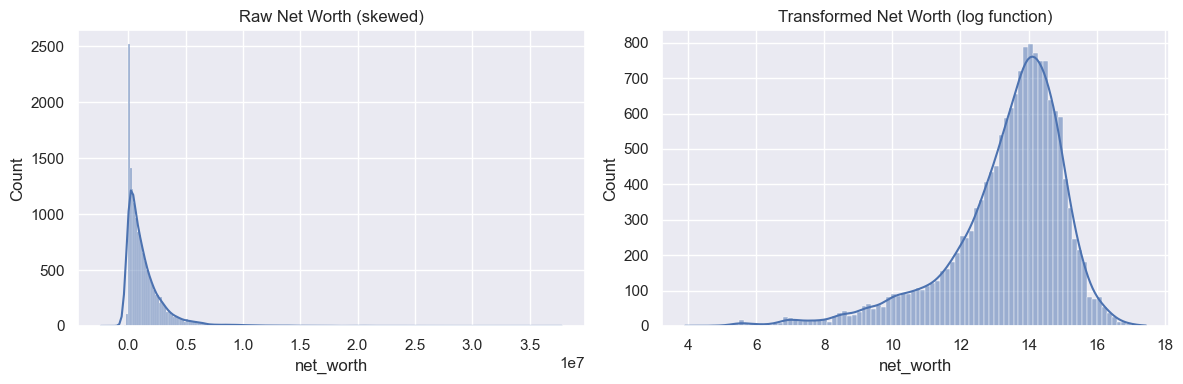

In [19]:
# Lets look at the distribution of the dollar columns
dollar_columns = ["income_after_tax","income_market","assets_total","net_worth",
                  "debt_total","debt_mortgage","debt_credit_card","debt_student_loan","debt_line_of_credit","debt_vehicle","debt_other"]

fig,(ax1,ax2) = plt.subplots(1,2, figsize=(12,4))
ax1=sns.histplot((df["net_worth"]),kde=True, ax=ax1)
ax2= sns.histplot(np.log(df["net_worth"]),kde=True, ax=ax2)

ax1.set_title("Raw Net Worth (skewed)")
ax2.set_title("Transformed Net Worth (log function)")
plt.tight_layout()
# net_worth is heavily right-skewed: most families sit low (that tall spike near 0),
# while a small number of very wealthy families stretch the tail out past $35M.
# (The axis also dips below 0 - families who owe more than they own.)
# Because of that skew, the median is the honest "typical" number here,
# not the mean - the mean gets dragged up by those few rich outliers.
# I applied a log function onto net_worth to make it roughly normal - since the graph was skewed.
# By applying the log function the families with net_worth <= 0 drop out of the plot (not the dataframe) -
# log(0) returns -inf and log(negative) returns NaN, so those families simply can't be drawn on the log panel
# Data will likely need to be transformed in sections 2 and 3
print("Families that vanished after log transformation: ",(df["net_worth"] <= 0).sum())

<a id="s1-9-2"></a>
### 1.9.2 The dollar columns - all 11 distributions

Same two views, now for all 11 dollar columns. The story repeats everywhere: heavily right-skewed raw, far more bell-like on the log axis. The debt columns add one wrinkle - a big spike at zero, because plenty of families simply don't carry a given kind of debt.

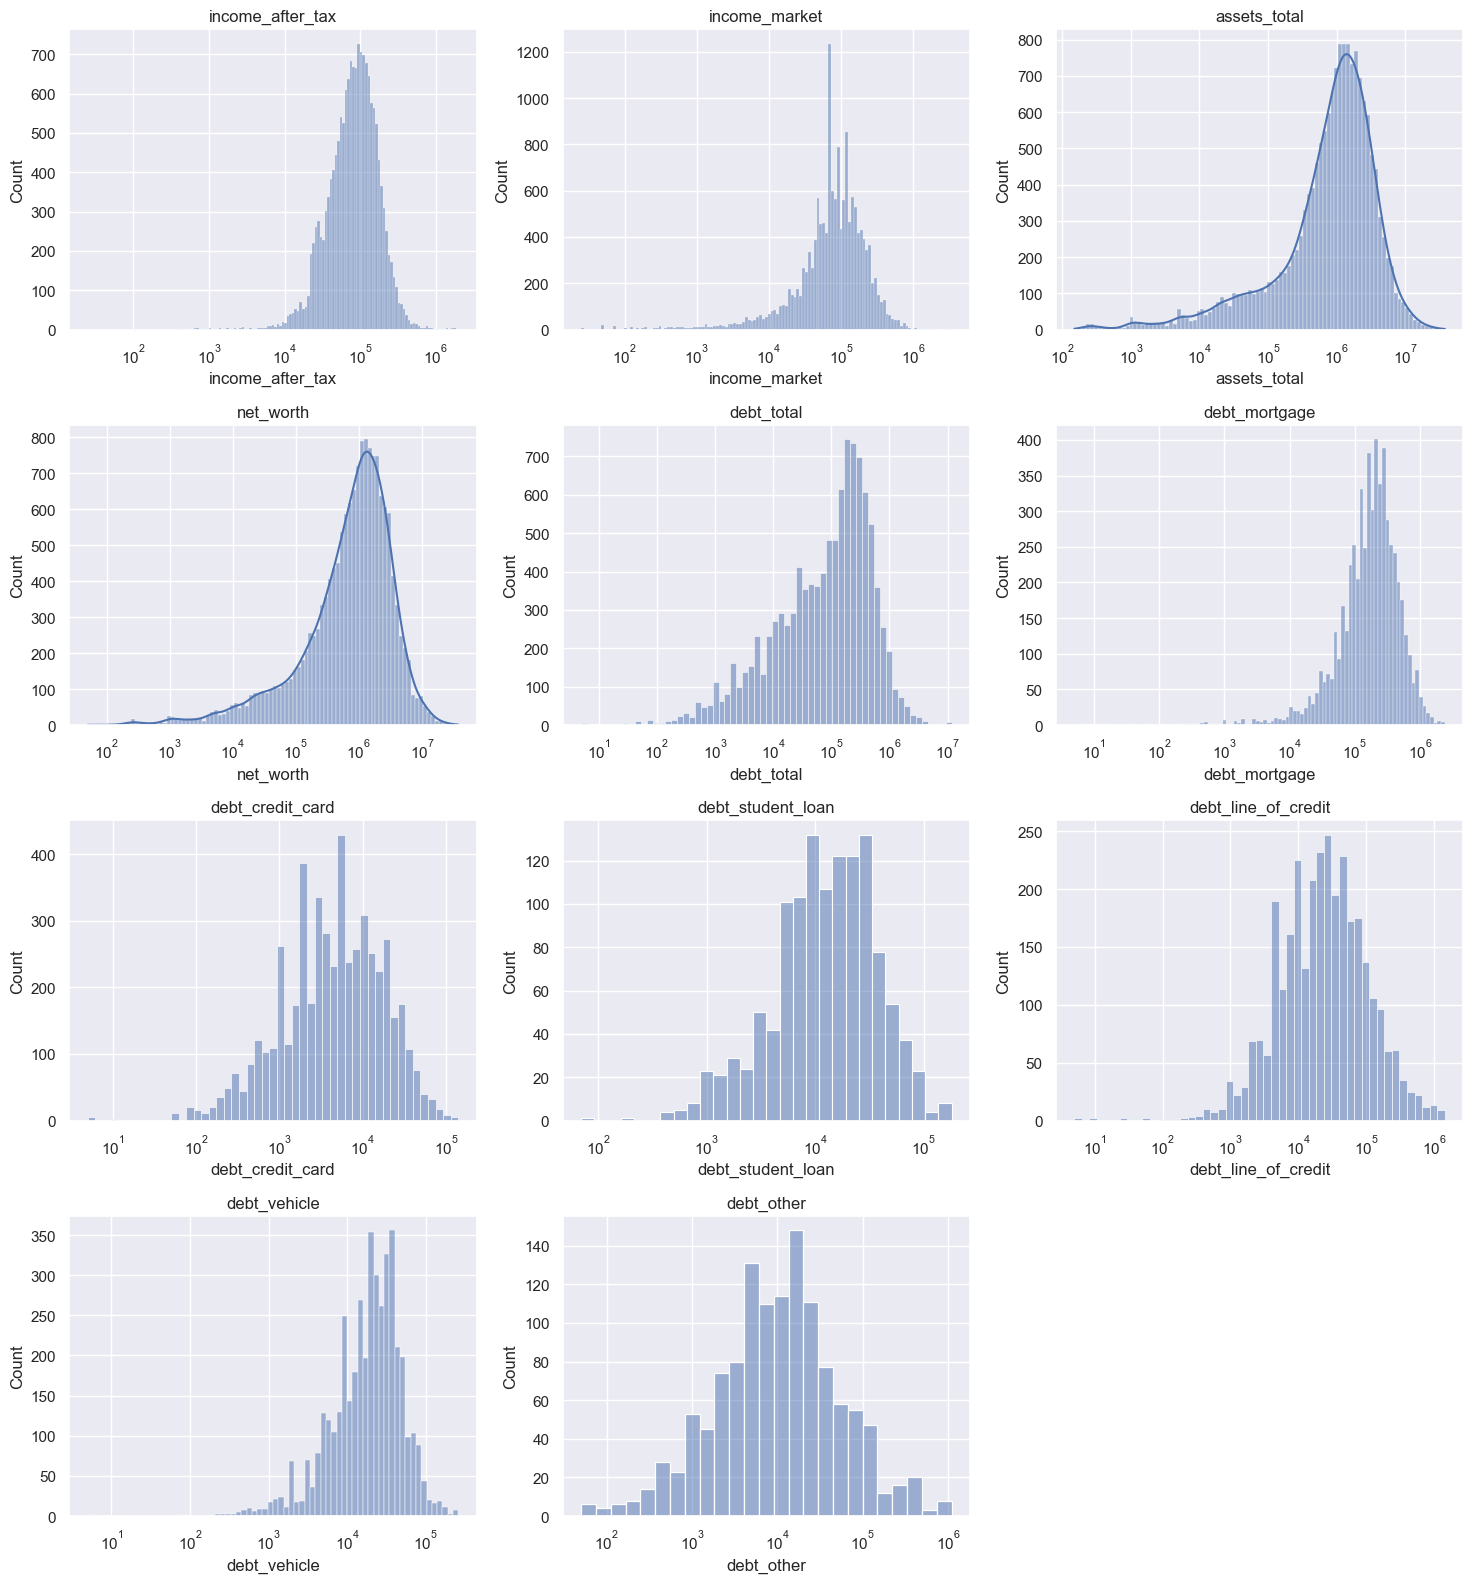

In [20]:
# lets repeat what we did for the columns in the dollar columns
fig,axes = plt.subplots(4,3, figsize=(15,16))
axes = axes.flatten() # flattening the axes to make the loop easier and avoid the annoyance behind indexing in a loop

for position, column_name in enumerate(dollar_columns):
    sns.histplot(df[column_name],kde=True, ax=axes[position],log_scale=True) # adding log_scale for x axis to space the ticks logarithmically
    axes[position].set_title(column_name)



plt.tight_layout() # stop the subplots from overlapping
fig.delaxes(axes[11]) # remove the extra subplot


# Plotting all 11 dollar columns at once. The pattern jumps out right away:
# every single one is skewed to the right. There's a big pile of families
# bunched up at the low end and then a long thin tail stretching out to the
# far right (a handful of very high income / high asset / high debt families).
# So the net worth skew I saw earlier isnt a one off, it's the whole dollar
# family behaving the same way. Mean would get dragged up by that tail, so
# median is the more honest middle for these. This is also why a log transform
# keeps coming up, it pulls that long tail in and makes the shape readable.
# Based off the graph below we can apply the log function to normalize and transform the data for our work.

# Note the graph shows the x axis transformed with log, if you remove log_scale= True or set it to False you will see the original skew mentioned

# One catch with log_scale=True: it silently drops the zeros and negatives, so each debt panel
# only shows the families that actually hold that debt - the plotted count differs from panel
# to panel, it's not all 16,241 families in every chart.


<a id="s1-9-3"></a>
### 1.9.3 Correlations between the dollar columns

How the dollar columns move together - a correlation heatmap, plus a rank-based cross-check underneath so the skew and the extreme values can't fake or hide a relationship. The number to remember: `assets_total` and `net_worth` at 0.98, nearly the same information twice. That flag comes back in [3.2.2](#s3-2-2) when the features get chosen.

Text(0.5, 1.0, 'Correlation between the dollar columns (Pearson)')

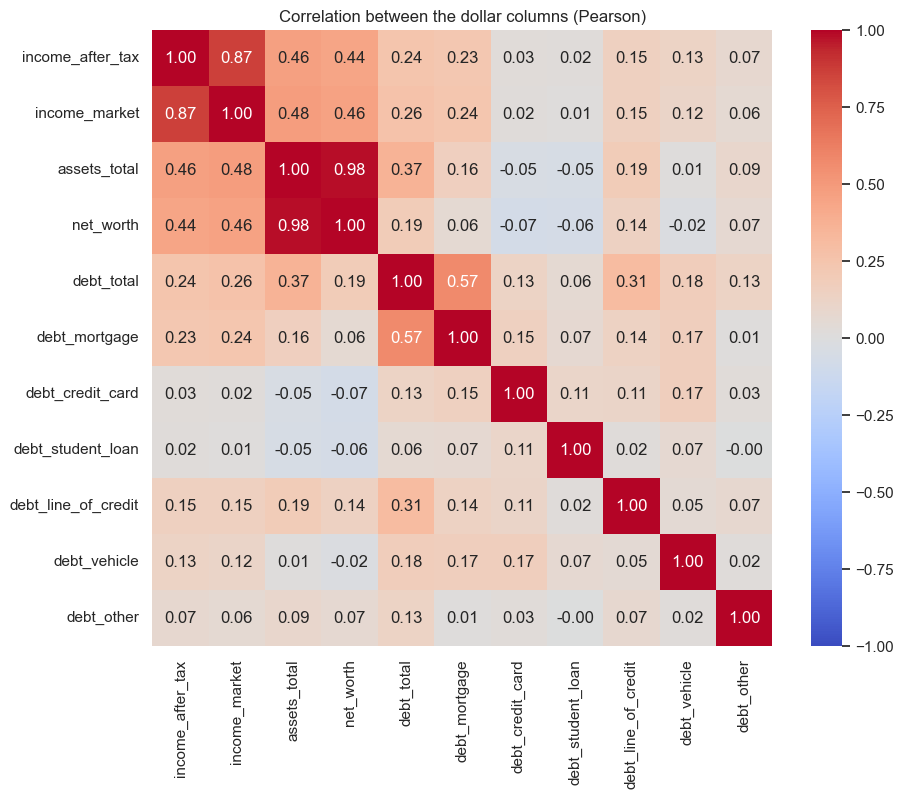

In [21]:
plt.figure(figsize=(10,8))   # the default figure is too small for an 11x11 annotated matrix
sns.heatmap(df[dollar_columns].corr(), annot=True, cmap="coolwarm", center=0, vmin=-1,vmax=1,fmt=".2f")
plt.title("Correlation between the dollar columns (Pearson)")

# Correlation of the 11 dollar columns. Strongest links are the near-duplicates:
# assets_total vs net_worth (0.98) and the two income columns (0.87). debt_total
# vs debt_mortgage is moderate (0.57). The separate debt types barely correlate,
# so they carry independent info. Watch the 0.98/0.87 pairs for multicollinearity
# at feature selection. Note: Pearson + skewed data, so read magnitudes loosely.

Text(0.5, 1.0, 'Correlation between the dollar columns (Spearman rank)')

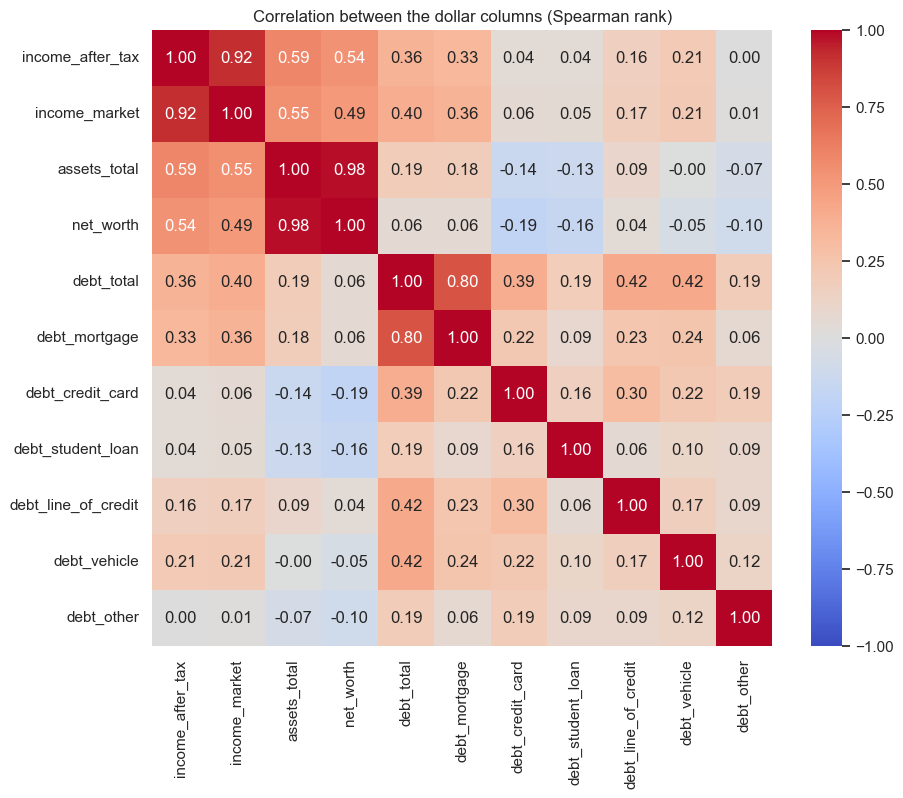

In [22]:
# Cross-check: the same heatmap but with Spearman instead of Pearson.
# Why: Pearson measures a straight-line fit on the raw dollar values, so a handful of
# very rich families can dominate the numbers - that's why the magnitudes above should
# be read loosely. Spearman ranks every family first (poorest to richest) and correlates
# the ranks, so it only asks "when one goes up, does the other tend to go up?" - outliers
# can't drag it around. Where the two maps disagree a lot, that's the outliers talking;
# where they agree, the relationship is real.

plt.figure(figsize=(10,8))
sns.heatmap(df[dollar_columns].corr(method="spearman"), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between the dollar columns (Spearman rank)")

# What actually changed between the two maps:
# - debt_total vs debt_mortgage jumped from 0.57 (Pearson) to 0.80 (Spearman). The real link
#   is stronger than Pearson showed - a few families with extreme debts were masking it.
# - the two income columns went 0.87 -> 0.92, same story on a smaller scale.
# - debt_credit_card vs net_worth flipped clearly negative (-0.19): the higher a family ranks
#   on wealth, the lower it tends to rank on credit-card debt. Carrying credit-card balances
#   is a low-wealth pattern - worth remembering for the model.
# - the near-duplicate held: assets_total vs net_worth is 0.98 on both maps, so that pair
#   stays on the multicollinearity watch list either way.

<a id="s1-9-4"></a>
### 1.9.4 The categorical columns - counts

Counts for the coded columns - how the families spread across each category's levels. The standout is the imbalance in the three missed-payment flags: the "yes" side is only 1 to 6 percent depending on the flag - the first warning of the class imbalance Section 3's model has to take seriously.

In [23]:
# the coded / categorical columns (labels, not dollar amounts) - used for the countplots and violin splits below
categorical_columns =["age_group","education", "gender","retired","visible_minority","income_main_source","income_expected_change","missed_pay_mortgage","missed_pay_nonmortgage","missed_pay_hardship" ]

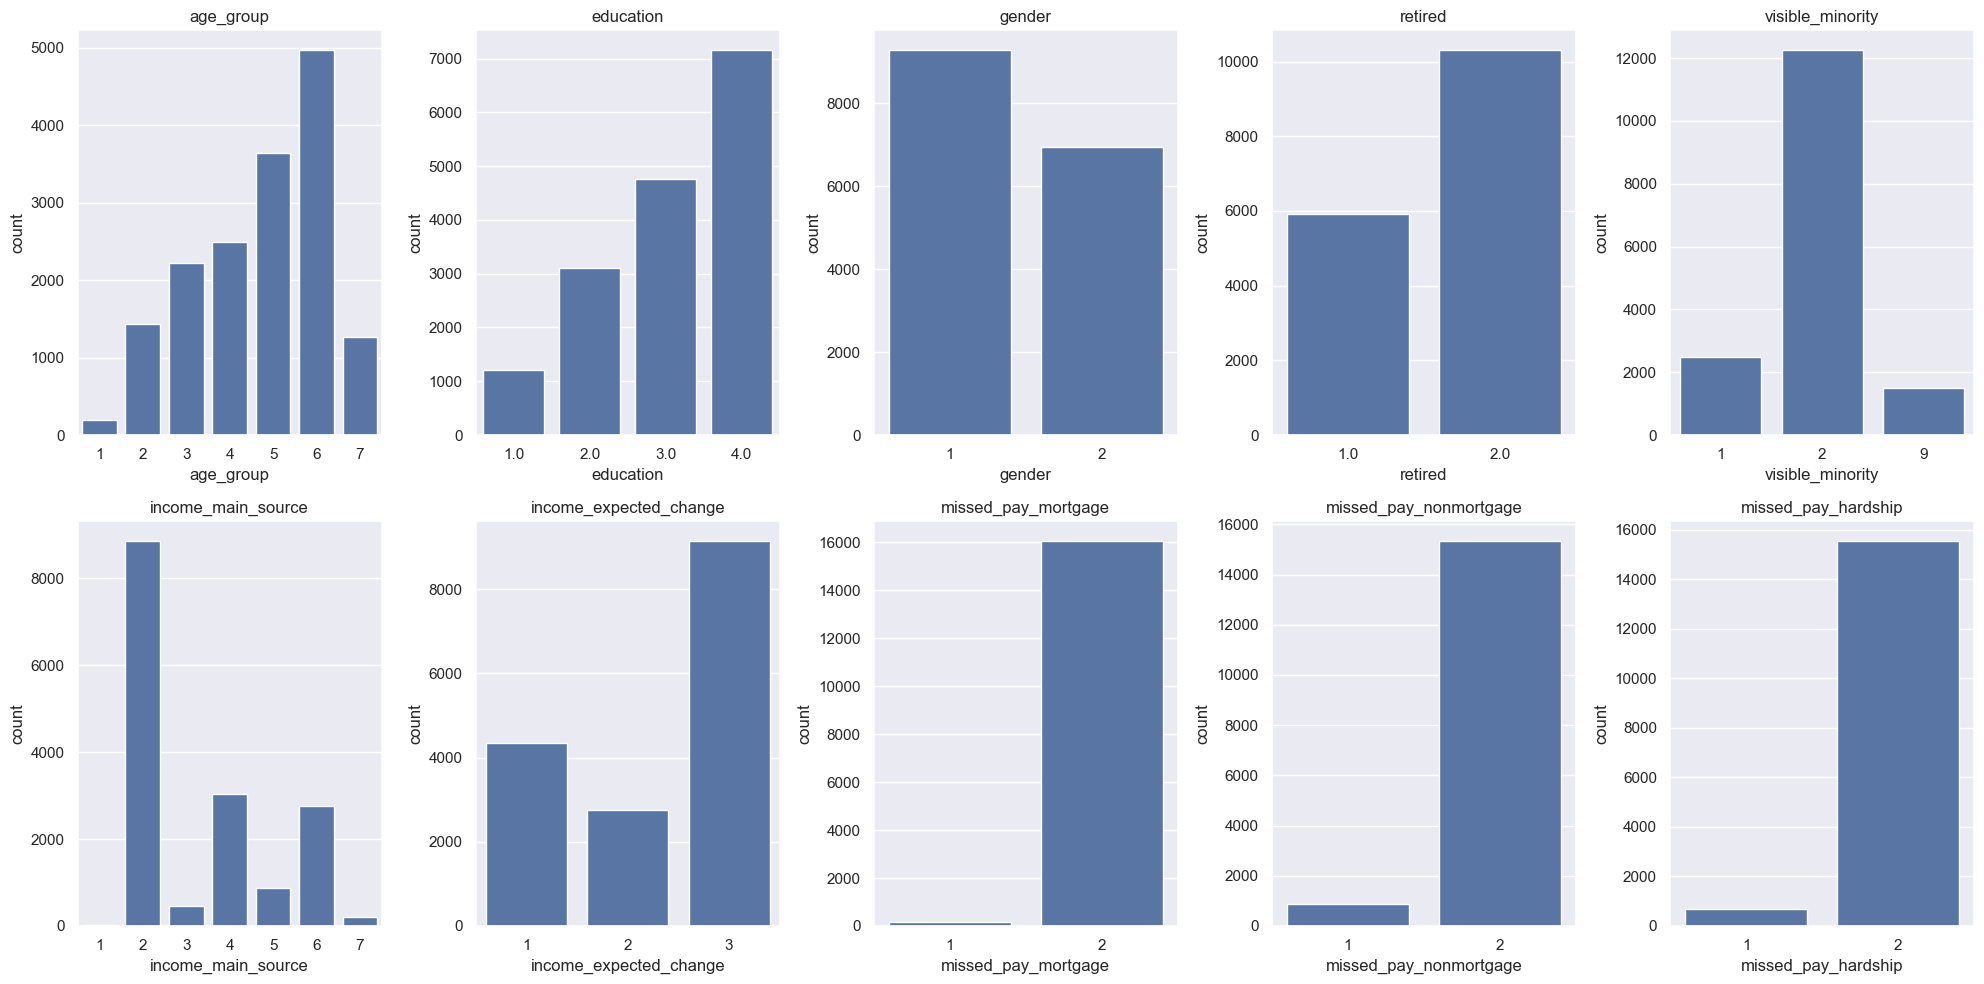

In [24]:
fig2,axes2 = plt.subplots(2,5, figsize=(20,10))
axes2 = axes2.flatten() # flattening the axes to make the loop easier and avoid the annoyance behind indexing in a loop

for position, column_name in enumerate(categorical_columns):
    sns.countplot(x=df[column_name],ax=axes2[position])
    axes2[position].set_title(column_name)
    
plt.tight_layout()

# Countplots for the 10 categorical columns. A few things worth noting:
#   This doubles as a check that my Section 1 cleaning worked. education only
#   shows 1-4 now (the code 9 got imputed away), retired only shows 1 and 2
#   (the valid skips and not-stated got folded into No), and visible_minority
#   still has its own 9 bar since I chose to keep that as unknown. All matches
#   what I did.
#   age_group skews older, the biggest group is 6 (65-79). education leans high,
#   most families sit at a university degree. wages (income_main_source = 2) are
#   by far the most common income source.
#   The big one for modelling: the three missed_pay / hardship flags are heavily
#   imbalanced. Almost everyone is a 2 (No) with only a thin slice of 1 (Yes),
#   roughly 1 to 6 percent depending on the flag. That imbalance is something I'll
#   have to deal with in Section 3 (class weights or resampling, and judging the
#   model on precision / recall and AUC instead of plain accuracy).


<a id="s1-9-5"></a>
### 1.9.5 Net worth across the categories

Net worth across each category's levels. Two climbs stand out - wealth rises steadily with age (older families have had a lifetime to accumulate) and with education - and the families who missed a payment under hardship sit visibly lower than everyone else. That last picture is the seed of Hypothesis 1.

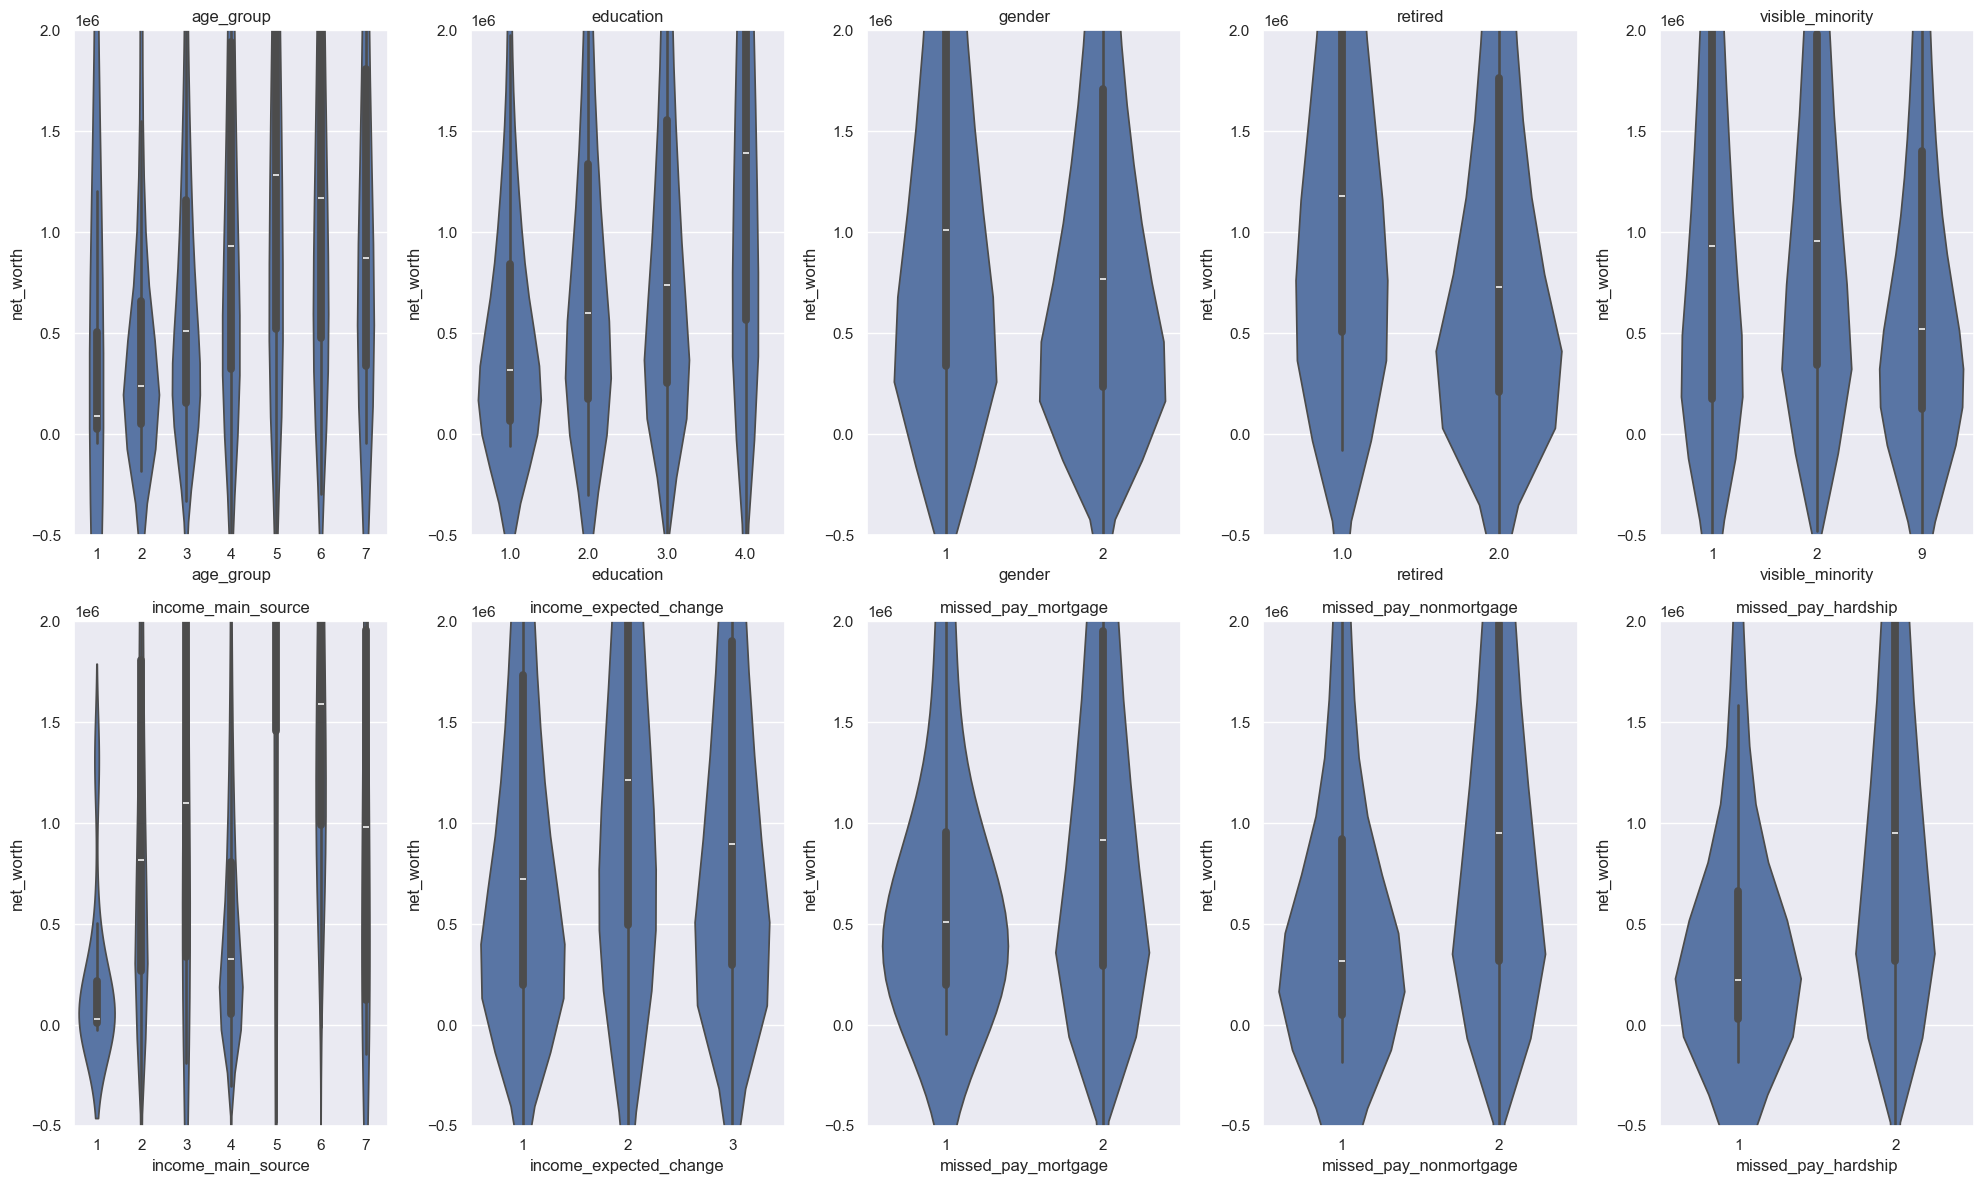

In [25]:
fig3,axes3 = plt.subplots(2,5, figsize=(20,12))
axes3 = axes3.flatten() # flattening the axes to make the loop easier and avoid the annoyance behind indexing in a loop

for position, column_name in enumerate(categorical_columns):
    sns.violinplot(x= df[column_name],y=df["net_worth"],ax=axes3[position])
    axes3[position].set_title(column_name)
    axes3[position].set_ylim(-500000, 2000000)

    
plt.tight_layout()


# Violin plots of net worth split across each categorical column. Net worth is on
# the y axis, and I capped it at -500000 to 2000000 so the shape is readable
# (a few families up in the tens of millions were stretching the axis and squishing
# everything else). The negative bottom is on purpose, it keeps the underwater
# families in view since those are the vulnerable ones I care about.
#
# How to read each violin:
# - the white dot is the median, the middle family in that group
# - the thick black bar is the middle 50% of families 
# - the thin black line is the fuller range
# - the blue shape is the distribution itself, fat where lots of families sit and
#   thin where few do (it's just mirrored to look like a violin)
# So I'm mainly looking at where the white dot sits and where the fat part is.
#
# What I see:
# - net worth climbs with age_group. Under 25 is bunched near zero, and it steps up
#   all the way to the older groups. Classic wealth building over a lifetime.
# - same staircase with education. University (4) has the highest median.
# - income_main_source has the biggest spread. Investment income (5) sits way up high,
#   which makes sense since you need wealth to earn it. Government transfers (4) sit low.
# - the vulnerability signal is in the three missed_pay flags. In each one, the group
#   that missed a payment or had hardship (1) sits clearly lower than the group that
#   didn't (2), lower median and bunched down near zero. So families showing payment
#   stress genuinely have less net worth cushion. That's the gap I'll test formally in
#   Section 2 (a t-test on net worth between the two groups).
#
# One caveat: these plots (and the counts above) are unweighted - they show the survey
# sample, not the weighted population. Fine for exploring shapes and gaps, but worth a
# line in the report's limitations later.

<a id="s1-9-6"></a>
### 1.9.6 Income after tax across the categories

The same view with income after tax - what's coming in now, where net worth is what's been built up over the years. It broadly agrees with the net-worth patterns, and together the two views feed straight into the wrap-up below.

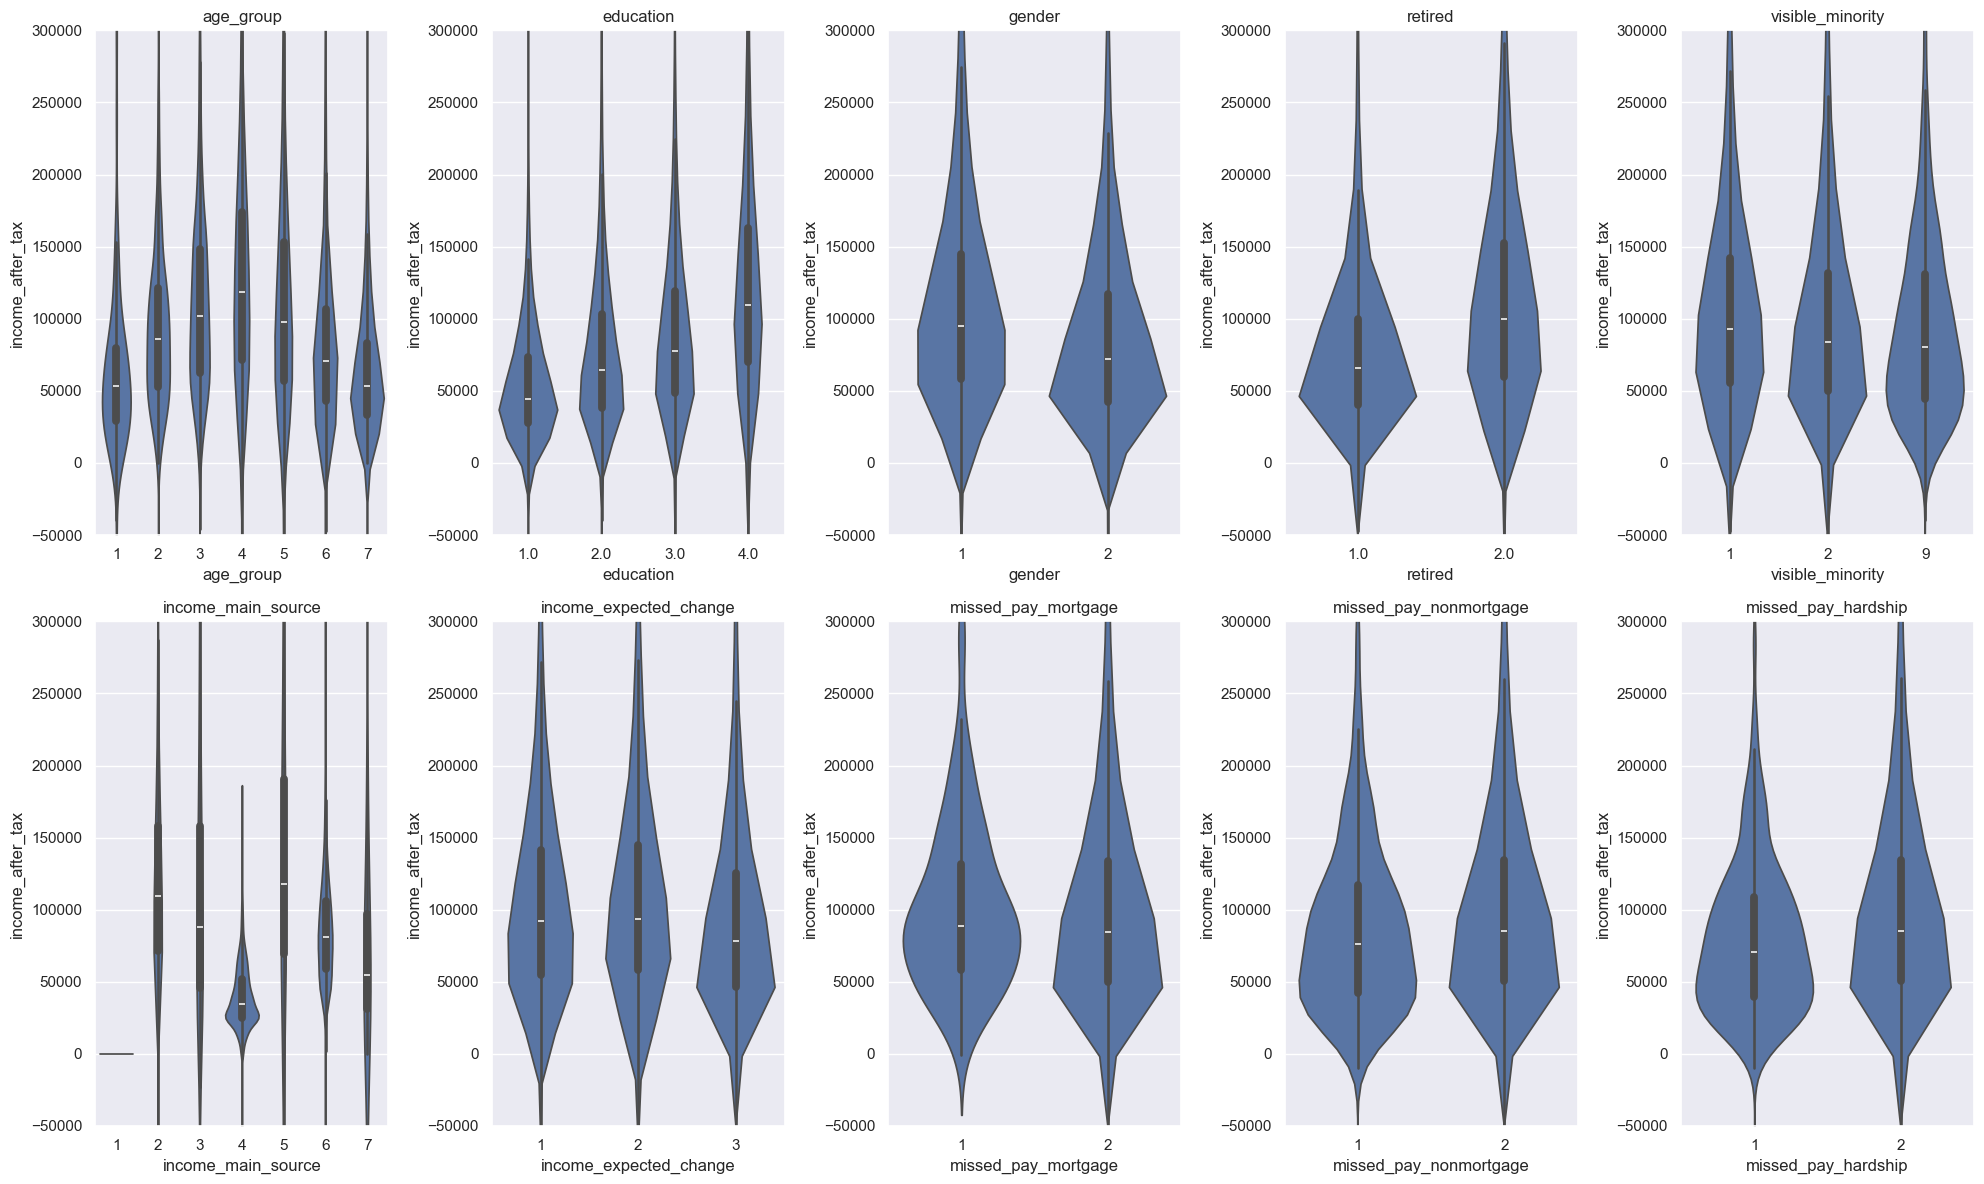

In [26]:
fig4,axes4 = plt.subplots(2,5, figsize=(20,12))
axes4 = axes4.flatten() # flattening the axes to make the loop easier and avoid the annoyance behind indexing in a loop
for position, column_name in enumerate(categorical_columns):
    sns.violinplot(x= df[column_name],y=df["income_after_tax"],ax=axes4[position])
    axes4[position].set_title(column_name)
    axes4[position].set_ylim(-50000, 300000)
    
plt.tight_layout()

# Same violin grid but for income_after_tax instead of net worth, capped at
# -50000 to 300000 since income sits on a much smaller scale. This gives me the
# cash flow view to go with the wealth view from the net worth plots.
#
# What I found:
# - income peaks in middle age (age_group 3-4) and drops in retirement, which is
#   the opposite of net worth. So retired families are wealth rich but income poor.
# - it still rises with education, and government transfers (income_main_source 4)
#   are clearly the lowest income group.
# - the missed_pay groups are a bit lower on income too, but the gap is smaller
#   than it was for net worth. So net worth separates vulnerable families more
#   sharply than income does.

<a id="s1-9-7"></a>
### 1.9.7 Wrapping up Section 1 - from the graphs to the hypotheses

The EDA gave me what I needed: a concrete target, two testable hypotheses, and a plan for the model. Here's where everything landed:

- **The target.** `missed_pay_hardship` is my definition of financially vulnerable - the families who skipped a payment because of financial difficulty (about 4% of the data). Three reasons. First, it's actual recorded behavior - Statistics Canada asked that question specifically to capture financial stress, so I'm not making up a cutoff like "net worth below X" and then having to defend it. Second, it matches how the industry measures distress: banks build their credit-risk models on payment behavior (late and missed payments), and the Bank of Canada tracks payment trouble alongside debt ratios in its household-vulnerability research. Third, a behavioral target means the balance-sheet columns stay available as predictors (more on that below). One caveat for the limitations section later: this captures families already missing payments, not families quietly draining their savings to stay afloat.
- **Hypothesis 1 - the wealth gap.** The violin plots showed hardship families sitting lower on net worth than everyone else. Section 2 tests whether that gap is real or just this sample: <u>do families that missed a payment due to hardship have significantly lower net worth than families that didn't?</u> That's a number compared across two groups, so it gets a t-test.
- **Hypothesis 2 - the education pattern.** The same violins showed net worth climbing step by step with education. If wealth and hardship are connected, the hardship *rate* should fall as education rises. So the second question: <u>does the rate of hardship depend on the education level of the family's main earner?</u> That's category against category (education 1-4, hardship yes/no) - there's no number to average, so a t-test can't touch it. This one gets a chi-square test, which checks whether two categorical columns are related. Between them, the two tests cover both question types.
- **Leakage guard for Section 3.** The target comes from `missed_pay_hardship`, so the two related flags stay out of the features: `missed_pay_nonmortgage` (the question that gates it) and `missed_pay_mortgage` (same kind of distress signal). The balance-sheet columns (net worth, assets, debts, incomes) stay in - that's the payoff of picking a behavioral target instead of a financial threshold.

This all lines up with the two questions in the Overview: the target makes "vulnerable" measurable, the two hypotheses are specific "what separates them" claims I can test in Section 2, and the Section 3 model handles the "can we predict it" half.

<a id="s2"></a>
# Section 2 - Hypothesis testing

Section 1 ended with two hypotheses, so this section tests them - one test each. Both follow the same routine:

1. State the question and the two competing explanations: **H0** (the boring one - "any pattern in my sample is just luck") and **H1** ("the pattern is real").
2. Run the test that fits the question type.
3. Read the result: if p comes in under alpha, H0 is rejected and the pattern stands.

**Alpha for both tests is 0.05.** Alpha is the risk I accept of a false alarm - calling a pattern real when it was actually luck (a Type I error). Accepting a 5% false-alarm risk is the same statement as working at a 95% confidence level, and 0.05 is the standard cutoff.

The two tests:
- **Test 1 - the wealth gap:** a number (net worth) compared across two groups (hardship yes/no) - a two-sample t-test.
- **Test 2 - the education pattern:** two categorical columns (education level, hardship yes/no) - a chi-square test of independence.

<a id="s2-1"></a>
## 2.1 Test 1 - the wealth gap (Welch's t-test)

**The question:** <u>do families that missed a payment due to hardship have significantly lower net worth than families that didn't?</u>

**The hypotheses:**
- **H0 (null):** the two groups have the same average net worth. The gap I saw in the graphs is just luck - a different sample of families could easily have shown no gap.
- **H1 (alternative):** the two groups really do have different average net worth - the gap is not luck.

**Why this test:** net worth is a number compared across two groups, so this is a two-sample t-test. I'm using **Welch's t-test**, the version that doesn't assume both groups have the same spread. Mine don't: the non-hardship group goes all the way up to multimillionaires while the hardship families are bunched near zero. The skew in net worth is also not a problem here - the test compares group averages, and with 672 and 15,569 families those averages behave normally even though the raw dollars are skewed (that's the central limit theorem).

**Choices made up front:**
- **Two-sided, not one-sided.** A one-sided test (only checking for "lower") is easier to pass, but you have to pick the direction before seeing any data - and my EDA already showed me the direction. Going one-sided now would be cherry-picking, so I test two-sided and report the direction from the group means.
- **Raw dollars, not log.** A log transform would tame the skew, but log breaks on the 358 families with zero or negative net worth - and those families are mostly in the hardship group. Transforming would drop the most vulnerable families from a test about vulnerability, so I keep the raw dollars. And skipping the transform costs nothing, because of the central limit theorem: the test runs on the group averages, not the raw values, and averages of samples this large (672 and 15,569) come out normally distributed even when the dollars behind them are skewed.

In [27]:
hardship_networth = df[df["missed_pay_hardship"]==1]["net_worth"]
no_hardship_networth = df[df["missed_pay_hardship"]==2]["net_worth"]

t,p = stats.ttest_ind(hardship_networth,no_hardship_networth,equal_var = False)

print(f'Hardship families average net worth: ${hardship_networth.mean():,.0f}')
print(f'Everyone else average net worth:     ${no_hardship_networth.mean():,.0f}')
print(f'The t-value is: {t:.2f} & the p-value is {p:.2e}')

if p <0.05:
        print("Reject H0 - statistically significant difference")
else:
        print("Failed to reject Null Hypothesis")

Hardship families average net worth: $594,939
Everyone else average net worth:     $1,543,399
The t-value is: -17.21 & the p-value is 8.31e-57
Reject H0 - statistically significant difference


**Reading the result.** The test gave t = -17.21 and p = 8.31e-57, so I reject H0 - the wealth gap between hardship families and everyone else is real, not luck. What each number means:

- **The t-value (-17.21)** measures how big the gap between the two group averages is compared to the random noise in the data. If the groups were truly the same, t would sit near 0, and around 2 is already enough to call a result significant. Mine is 17. The minus sign just says the first group I passed in (the hardship families) is the lower one - the direction the violins predicted.
- **The p-value (8.31e-57)** is the chance of a gap this big showing up if the two groups were actually the same - basically zero, and far below alpha, so H0 goes.

**What I expected and what I got:** the violins suggested hardship families sit lower on net worth, and the test confirms it as decisively as a test can - this wasn't a close call.

**What this does and doesn't say.** Hardship families have significantly less net worth on average - that part is now established. It does not say which causes which: thin savings could lead to missed payments, money trouble could drain savings, or something else like a job loss could drive both. The test only proves the gap is real, not why it's there. It's also a statement about averages, not every family - some hardship families are fine on net worth, and some non-hardship families are underwater.

**Where this leaves things.** Hypothesis 1 is confirmed - net worth separates vulnerable families from the rest. Next is test 2: whether the hardship rate follows education. Prediction comes after, in Section 3.

<a id="s2-2"></a>
## 2.2 Test 2 - the education pattern (chi-square)

**The question:** <u>does the rate of missed-payments-due-to-hardship depend on the education level of the family's main earner?</u> The violins showed net worth climbing with education, and test 1 confirmed hardship families hold less net worth - this test connects the two.

**The hypotheses:**
- **H0 (null):** hardship and education are unrelated - every education level has the same hardship rate, and any differences in my sample are luck.
- **H1 (alternative):** the hardship rate really does differ across education levels.

**Why this test:** both columns are categories (education 1-4, hardship yes/no) - there's no number to average, so a t-test can't touch this. A **chi-square test of independence** works on a count table instead: count how many families land in each education x hardship combination, work out what those counts would look like if the two columns had nothing to do with each other, and measure how far the real table sits from that "unrelated" picture. A big enough distance means the columns are connected.

**Choices made up front:**
- **The test runs on raw counts, not percentages.** Sample size is the evidence - 1 family out of 10 and 1,000 out of 10,000 are the same percentage but completely different proof. The test needs to know how many families it's looking at, so it gets the untouched count table.
- **A second, normalized table for reading the direction.** The chi-square only answers "related or not" - it won't say which education levels are risky or by how much. For that I'll convert each row to rates (normalize="index") and read the hardship column. One table proves, the other describes.

In [28]:
contingency_table = pd.crosstab(df.education,df.missed_pay_hardship)
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(contingency_table)
print()
print(f"chi2 = {chi2:.2f}")
print(f"p-value = {p:.2e}")
print(f"degrees of freedom = {dof}")
print(f"smallest expected count = {expected.min():.1f}")
print()
if p < 0.05:
    print("Reject H0 - hardship rate and education are related")
else:
    print("Fail to reject H0 - no evidence of a relationship")

missed_pay_hardship    1     2
education                     
1.0                   41  1162
2.0                  152  2952
3.0                  240  4526
4.0                  239  6929

chi2 = 27.48
p-value = 4.67e-06
degrees of freedom = 3
smallest expected count = 49.8

Reject H0 - hardship rate and education are related


In [29]:
contingency_table2 = pd.crosstab(df.education, df.missed_pay_hardship, normalize="index")
print((contingency_table2 * 100).round(1))

# Why a second table: the chi-square above only says the pattern is real - it doesn't show
# what the pattern is. The raw counts can't show it either, because the education levels are
# wildly different sizes: level 4 has 239 hardship families vs level 1's 41, which looks six
# times worse - but level 4 holds ~7,200 families and level 1 only ~1,200. normalize="index"
# divides each row by its own size, turning counts into rates: 41/1,203 = 3.4% vs
# 239/7,168 = 3.3% - university families are actually slightly safer, the opposite of what
# the raw counts suggest. The "1" column of this table (x100) is where the percentages in
# the reading below come from: 3.4%, 4.9%, 5.0%, 3.3%.

missed_pay_hardship    1     2
education                     
1.0                  3.4  96.6
2.0                  4.9  95.1
3.0                  5.0  95.0
4.0                  3.3  96.7


**Reading the result.** The test gave chi2 = 27.48 and p = 4.67e-06, so I reject H0 - there is a real association between education and the hardship rate. What each number means:

- **The chi2 value (27.48)** is the total distance between my real count table and the table you'd expect if education and hardship had nothing to do with each other. If they were truly unrelated, this number would sit near 3 (see degrees of freedom). Mine is 27.48 - far more separation than chance produces.
- **The p-value (4.67e-06)** is the chance of a table this lopsided showing up if the two columns were truly unrelated - about 5 in a million. Far below alpha, so H0 goes.
- **Degrees of freedom (3)** is how many cells in my table can move on their own. Once the row and column totals are locked in, filling in just 3 of the 8 cells forces all the rest - so the table has 3 "free" numbers, (4-1) x (2-1). The test needs this as its yardstick: bigger tables rack up more distance by pure chance, and for 3 degrees of freedom chance alone typically produces a chi2 around 3 - which is why 27.48 stands out.
- **Smallest expected count (49.8)** is the safety check. The chi-square's math only holds when every cell of the "unrelated" table expects at least about 5 families - if some combination were too rare, the p-value couldn't be trusted. Mine bottoms out at 49.8, so the test is on solid ground. This rule plays the same role for the chi-square that the central limit theorem plays for the t-test: both tests lean on an approximation that only becomes trustworthy with enough data - big group sizes there, big expected counts here.

**What I expected:** more education means more income, so fewer missed payments - a staircase, with hardship highest at the bottom education level and lowest at the top.

**What the data shows instead: an arch.** Reading the hardship rate per level from the rate table above (the "1" column, times 100): 3.4% (less than high school), 4.9% (high school), 5.0% (post-secondary), 3.3% (university). The middle education levels carry the most hardship, and the two ends are the safest - nearly tied. The chi-square says these differences are far too big to be coincidence.

**The university end makes sense** - a degree usually means higher income, and the bills get paid. **The puzzle is the least-educated group being safe.** If education were what protects families, that group should be the most vulnerable - instead it has nearly the lowest rate. The likely explanation is age: decades ago far fewer Canadians finished school, so "less than high school" today is heavily older families - and my violins showed older families hold the most wealth. They don't miss payments because they're sitting on a lifetime of savings and often have no payments left to miss, not because low education protects them.

**The honest conclusion:** education is associated with hardship, but it's probably not the whole cause - age and accumulated wealth are tangled up inside the arch. A chi-square can only compare two columns at a time, so it can't separate the education effect from the age effect. That's Section 3's job: with education, age, and net worth all in the model at once, it can show whether education still matters after accounting for age - or whether the arch was mostly age wearing an education costume.

**Where this leaves things.** Both hypotheses are confirmed: vulnerable families hold less wealth (test 1), and hardship isn't spread evenly across education (test 2). That closes Section 2. Next is the second half of the project: can we predict which families are vulnerable?

<a id="s3"></a>
# Section 3 - Machine-learning model

Section 2 established that vulnerable families really are different - they hold less net worth, and hardship isn't spread evenly across education. This section takes on the Overview's second question: <u>can we predict which families are vulnerable?</u>

What the model gets to work with:
- **The target:** `missed_pay_hardship` (1 = vulnerable, about 4% of families).
- **The features:** the family's finances and demographics, including a new engineered column (debt-to-income, below) - but **not** `missed_pay_nonmortgage` or `missed_pay_mortgage` (too close to the target - leakage, per 1.9.7), and not `family_id` or `weight` (metadata, not information about the family).
- **The known challenge:** only ~4% of families are vulnerable. A model that predicts "nobody is vulnerable" would be 96% accurate and completely useless - so accuracy is banned as a grade. The models get class weights to take the rare class seriously, and the grading is precision, recall, and AUC. Of these, recall matters most for this problem - catching vulnerable families is the goal, so missing one costs more than a false alarm; AUC is used to compare the two models, and f1 (which the tuning runs on) balances precision and recall.

The plan, grouped into the standard machine-learning workflow stages. (Preprocessing actually started back in Section 1 - the imputations and recodes there were preprocessing before this section gave it the name.)

**Preprocessing**
1. **3.1** - engineer the debt-to-income feature and clean its edge cases
2. **3.2** - build the target (y) and the feature table (X)
3. **3.3** - build the column transformer (encoding + scaling)

**Split**

4. **3.4** - split into train and test *first*, then fit the column transformer on the training half and transform both. Splitting before fitting is deliberate - it keeps the test families out of the settings the column transformer learns (the leakage guard, detailed in 3.4.2)

**Models** *(the 3.3 column transformer handles the scaling, fitted on the training data in 3.4)*

5. **3.5** - logistic regression: the interpretable baseline
6. **3.6** - random forest: the tree ensemble, plus hyperparameter tuning (cross-validated grid search)

**Interpretation**

7. **3.7** - read the models: what drives vulnerability, and can we predict it?

<a id="s3-1"></a>
## 3.1 New feature - debt-to-income (the Bank of Canada's indicator)

Before assembling the features, I'm adding one column the dataset doesn't have: **`debt_to_income` = `debt_total` / `income_after_tax`** - how many years of income it would take to clear the family's debt. Two reasons it earns a spot:

- A 50K debt means nothing on its own - it's a car loan for a family earning 200K and a crisis for a family earning 25K. The *ratio* captures a fact neither column carries alone, so I'm handing the model that comparison instead of hoping it figures it out.
- DTI has long been the headline household-vulnerability indicator in the Bank of Canada's Financial System Review and a core input in bank lending decisions - the exact number the institutions this project speaks to already watch.

**The edge cases.** Dividing by income breaks for families whose income is zero or negative - 45 families in total (~0.3% of the data):

- **13 families with no debt and no income** (0 ÷ 0 = NaN): no debt means no debt burden - their honest DTI is **0**.
- **7 families with debt and zero income** (÷ 0 = infinity): debt with nothing coming in - arguably the most debt-stressed families in the data. They belong at the **top** of the scale, not deleted.
- **25 families with debt and negative income** (negative DTI, which would read as *least* indebted - nonsense): same story as the zero-income group - **top** of the scale.

So the recipe: fill the NaNs with 0, then cap the column at its **99th percentile (15.91)** rather than the raw maximum - the biggest finite values (up to 7,401) turned out to be the same near-zero-income artifact as the infinities, so everything above the cap gets pulled down to it, and the negatives get pushed up to it. Each group worked through below.

In [30]:
df["debt_to_income"] = df["debt_total"]/df["income_after_tax"]   # the BoC indicator: years of income needed to clear the debt
print(f"The count of null values is: {df.debt_to_income.isna().sum()}")   # 0/0 families - no debt, no income

The count of null values is: 13


In [31]:
# count the infinity values - families with debt but ZERO income (isna does not catch inf)
print(f"The count of infinity values is: {np.isinf(df.debt_to_income).sum()}")

The count of infinity values is: 7


In [32]:
# count families with a NEGATIVE ratio - debt divided by negative income (reads backwards)
print(f"The count of negative values is: {(df.debt_to_income < 0).sum()}")

The count of negative values is: 25


In [33]:
# what the three problem groups mean, in plain terms:
print("13 NaN -> no debt AND no income (0/0). No debt = no debt burden -> fill with 0")
print(" 7 inf -> debt but zero income. The most debt-stressed families here -> cap at the top of the scale")
print("25 neg -> debt with negative income. At least as stressed as zero income -> same cap")
print()
print("Total: 45 of 16,241 families (~0.3%) - each gets an honest value instead of being dropped")

13 NaN -> no debt AND no income (0/0). No debt = no debt burden -> fill with 0
 7 inf -> debt but zero income. The most debt-stressed families here -> cap at the top of the scale
25 neg -> debt with negative income. At least as stressed as zero income -> same cap

Total: 45 of 16,241 families (~0.3%) - each gets an honest value instead of being dropped


<a id="s3-1-1"></a>
### 3.1.1 The nulls - no debt, no income (13 families)

0 divided by 0 gives NaN - and the arithmetic guarantees who these families are: a NaN can only happen with a zero on top, so all 13 must have no debt at all (verified below - both columns come back pure zeros).

**Why fill with 0.** This isn't an imputation like Section 1's - there I was estimating values I couldn't know; here I know the truth exactly, the formula just couldn't say it. No debt means no debt burden: a family with zero debt and a 100K income gets DTI = 0 computed normally, and these 13 are in the identical debt situation - so 0 is their true ratio, not a guess. Their zero income is a real problem, but that signal already lives in `income_after_tax` - each column tells one truth, and DTI's truth here is "no debt stress."

In [34]:
# Verify the NaNs really are 0/0 families - all 13 rows should show zero debt and zero income
print(df[df.debt_to_income.isna()][["debt_total", "income_after_tax"]])

# No debt = no debt burden: 0 is their TRUE ratio, not a guess (unlike the Section 1 imputations).
# Their zero income is a real problem, but that signal is already carried by income_after_tax.
df["debt_to_income"] = df["debt_to_income"].fillna(0)

print(f"The count of null values is now: {df.debt_to_income.isna().sum()}")   # expecting 0

       debt_total  income_after_tax
696             0                 0
3466            0                 0
3945            0                 0
4229            0                 0
5390            0                 0
5738            0                 0
5895            0                 0
7107            0                 0
10142           0                 0
12873           0                 0
13809           0                 0
14077           0                 0
15785           0                 0
The count of null values is now: 0


<a id="s3-1-2"></a>
### 3.1.2 The infinities - debt, zero income (7 families)

Debt divided by zero income gives infinity, which no model can digest. These families are among the most debt-stressed in the data, so they belong at the **top** of the scale, not deleted.

**Why cap at the 99th percentile (15.91), not the max.** The largest finite DTI is 7,401 - seven thousand years of income to clear the debt, which isn't real, it's just division by a near-zero income. Those extreme finite values are the same near-zero-denominator problem as the infinities, so I treat them together: everything above 15.91 gets capped there (winsorizing). This catches the 7 infinities plus ~170 artifact values in one move. The cost - families above the cap all become 15.91 - doesn't matter, since past "16 years to pay off" they're all just maximally debt-stressed. The payoff is a sane range that won't wreck the feature scaling in 3.3's column transformer.

In [35]:
# scout the cap candidates: the raw maximum vs the 99th percentile (finite values only -
# the infinities are still in the column here and would drag both numbers if not filtered out)
print('Max DTI Value: ',df[np.isfinite(df.debt_to_income)].debt_to_income.max(), 'years are needed for this family to clear their debt')
print('Top 1% DTI: ',round(df[np.isfinite(df.debt_to_income)].debt_to_income.quantile(0.99),2),'years of income to clear the debt - the doorway into the top 1% (about 170 families)')

Max DTI Value:  7401.0 years are needed for this family to clear their debt
Top 1% DTI:  15.91 years of income to clear the debt - the doorway into the top 1% (about 170 families)


In [36]:
# preview how many values the cap will pull down (infinity counts as above the cap, so the 7 infs are in here)
print(f"Values at or above the cap: {(df.debt_to_income >= 15.91).sum()}")

Values at or above the cap: 170


In [37]:
# cap = 99th percentile of the FINITE values (excluding the infs so they don't drag the cutoff up)
cap = round(df[np.isfinite(df.debt_to_income)].debt_to_income.quantile(0.99),2)
# winsorize: pull everything above the cap down to it - handles the 7 infinities and the artifact extremes in one move
df['debt_to_income']=df.debt_to_income.clip(upper = cap)

In [38]:
print('Max Value: ',df.debt_to_income.max())# double checking to see if the change went through
print('Remaining Infinite Value: ',np.isinf(df.debt_to_income).sum())

Max Value:  15.91
Remaining Infinite Value:  0


<a id="s3-1-3"></a>
### 3.1.3 The negatives - debt, negative income (25 families)

**Why they go up to the cap, not down to zero.** A negative DTI comes from debt divided by *negative* income - a family that owes money and is losing money on top of it. Read literally, a negative ratio would rank them as the *least* indebted families in the data, which is exactly backwards - they're at least as stressed as the debt-with-zero-income families from 3.1.2. So they get the same treatment: pushed up to the cap, at the top of the honest scale, where the most debt-stressed families belong.

With all three groups handled, the column is clean and ready for the model - no nulls, no infinities, no negatives - running from 0 (families carrying no debt) up to the cap (families in the deepest debt stress).

In [39]:
df['debt_to_income'] = df.debt_to_income.apply(lambda x: cap if x <0 else x) # for each value: if negative, push it up to the cap; otherwise keep it
print('Remaining Negative DTI: ',(df.debt_to_income < 0).sum()) # checking to see if the implementation worked

Remaining Negative DTI:  0


In [40]:
df.debt_to_income.describe() # final check on the finished column: min 0 (no-debt families), max 15.91 (the cap), no broken values left

count    16241.000000
mean         1.407747
std          2.576278
min          0.000000
25%          0.000000
50%          0.281273
75%          1.836327
max         15.910000
Name: debt_to_income, dtype: float64

<a id="s3-2"></a>
## 3.2 The target and the features (y and X)

Supervised learning splits the data into two objects: **y**, the answer column (what we want to predict), and **X**, the information table (what the model is allowed to look at). The model's whole job is learning the pattern that connects X to y.

**Building y.** The target is `missed_pay_hardship`, recoded from 1/2 to **1/0 with vulnerable = 1**. The convention matters: the class you're hunting gets the 1, so that "positive" means "vulnerable" in every score and report downstream. That leaves 672 ones and 15,569 zeros.

**Building X.** Everything else stays in - including the new `debt_to_income` - except five columns, each with a reason:
- `missed_pay_hardship` - the target itself. A model that sees the answer column isn't predicting, it's copying.
- `missed_pay_nonmortgage` and `missed_pay_mortgage` - the leakage flags from 1.9.7. They're near-copies of the answer (one literally gates the target question), so including them would inflate the scores while teaching us nothing.
- `family_id` - an arbitrary label. It carries no facts about the family, and a model can abuse it to memorize rows.
- `weight` - survey bookkeeping (how many real families this row stands for), not a property of the family itself.

That leaves X at 19 columns - then one more judgment call inside 3.2.2 brings it to 18.

<a id="s3-2-1"></a>
### 3.2.1 The target (y)

`missed_pay_hardship`, recoded so the hunted class is the 1: vulnerable = 1, everyone else = 0. Built as its own variable, leaving the original column untouched - 672 ones and 15,569 zeros, the same split every count in this notebook has agreed on.

In [41]:
y = df.missed_pay_hardship.replace(2,0)
print(y.value_counts())

missed_pay_hardship
0    15569
1      672
Name: count, dtype: int64


<a id="s3-2-2"></a>
### 3.2.2 The features (X)

Everything except the five columns ruled out in the header above: the target itself, the two leakage flags (`missed_pay_nonmortgage`, `missed_pay_mortgage`), and the two metadata columns (`family_id`, `weight`). The new `debt_to_income` rides along, leaving 19 columns.

*Leakage* is when a feature secretly carries the answer - `missed_pay_nonmortgage` is the gate question the target sits inside (no skipped payment = no hardship, automatically), so it's a near-copy of the target rather than a real fact about the family. Left in, it would inflate the scores while teaching nothing.

**One judgment call on top - the near-duplicate.** The 1.9.3 heatmap flagged `assets_total` and `net_worth` at 0.98 correlation. They're not the same number: net worth = assets minus debts, so the two are only *equal* for families with nothing to subtract - and the check below confirms it, the share of families where they match and the share with zero debt land on the same ~34%. For everyone else the two move in near-lockstep, which is what redundancy actually means. Keeping both would hand the model the same fact twice. The forest doesn't mind, but the logistic regression does: wealth has one real effect on vulnerability, and with two near-identical columns the model can't tell which one deserves the credit for it - so it splits the credit arbitrarily, and that split can come out completely different on a slightly different sample. The predictions stay fine, but the per-feature numbers I actually care about (the odds ratios) stop being trustworthy. Since interpretation is half this project's promise, one goes: **keep `net_worth`** (the more complete measure - it already accounts for debt, and it's the one Section 2 tested) and **drop `assets_total`**. 

In [42]:
X = df.drop(columns = ["missed_pay_hardship","weight","family_id","missed_pay_nonmortgage","missed_pay_mortgage"] )

In [43]:
# how alike are assets_total and net_worth? exact equality vs moving together:
print('Families where assets equal net worth: ', round((df.assets_total == df.net_worth).mean(),2))   # equal only when there is nothing to subtract...
print('Families with zero debt:                ', round((df.debt_total == 0).mean(),2))                # ...same share - equal means debt-free
print('Correlation (the real redundancy test): ', round(df.assets_total.corr(df.net_worth),2))         # 0.98 - they move in near-lockstep

Families where assets equal net worth:  0.34
Families with zero debt:                 0.34
Correlation (the real redundancy test):  0.98


In [44]:
X= X.drop(columns =["assets_total"])
print(X.shape)
X.head()

(16241, 18)


,income_after_tax,income_market,income_main_source,income_expected_change,net_worth,debt_total,debt_mortgage,debt_credit_card,debt_student_loan,debt_line_of_credit,debt_vehicle,debt_other,age_group,education,gender,retired,visible_minority,debt_to_income
0,115525,125000.0,6,1,3713000,30000,0,0,0,0,30000,0,6,4.0,2,1.0,2,0.259684
1,121300,67500.0,6,3,1740900,227500,0,0,0,145000,0,0,7,3.0,2,1.0,2,1.875515
2,19175,31000.0,7,3,3672500,40000,0,0,0,40000,0,0,5,4.0,1,1.0,2,2.086050
3,147425,140000.0,2,3,2809050,227000,180000,18500,0,10000,18500,0,6,4.0,1,1.0,2,1.539766
4,56750,65000.0,2,3,471900,0,0,0,0,0,0,0,4,3.0,2,2.0,1,0.000000


<a id="s3-3"></a>
## 3.3 Preprocessing - encoding and scaling

Two transformations stand between X and a model-ready table, and each applies to a different set of columns:

- **Encoding, for the category columns.** The model does math on every number it's given, and codes like `income_main_source`'s 7 ("other income") vs 6 ("retirement pensions") are labels, not amounts - 7 isn't *more than* 6. One-hot encoding fixes that: each category becomes its own yes/no column, so no fake ranking survives.
- **Scaling, for the numeric columns.** The dollar features live in the millions while the coded ones live in single digits - unscaled, the big numbers would dominate the logistic model's math by sheer size rather than importance. Scaling puts every feature on the same ruler.

Both jobs go into one **column transformer**: each set of columns gets its own transformer, and it routes every column to the right one and glues the results into one table.

One discipline on top: the column transformer only gets **defined** here - it doesn't touch the data yet. Scaling has numbers to learn (each feature's smallest and largest values, for the 0-1 squeeze), and those get learned from the *training* families only - so the column transformer fits right after the split in 3.4.

<a id="s3-3-1"></a>
### 3.3.1 Sorting the columns into the two branches

Same nominal-vs-ordinal calls as Section 1, now with consequences:

- **The encoding branch - five nominal columns:** `income_main_source` (7 codes), `income_expected_change` (3), `gender` (2), `retired` (2), `visible_minority` (3, including the "unknown" 9 kept back in 1.7.3 - it simply becomes its own yes/no column, which is exactly what keeping it as a category was for).
- **The scaling branch - the other 13 columns:** the dollar features, `debt_to_income`, and the two ordinals `age_group` and `education`. The ordinals ride with the numerics on purpose: their order is real information (a university degree genuinely is more education than high school), and one-hot encoding would throw that ranking away.

In [45]:
categorical_columns = ["income_main_source","income_expected_change","gender","retired","visible_minority"]   # the five nominal columns - the encoding branch
numerical_columns = [col for col in X.columns if col not in categorical_columns]   # everything else in X - the scaling branch (computed, so nothing gets missed)

<a id="s3-3-2"></a>
### 3.3.2 Building the column transformer

Each branch is a single transformer: the category columns go to the one-hot encoder, the numeric columns to the scaler. (No impute steps needed - Section 1 already filled every hole, so imputers here would be steps that do nothing.) The column transformer holds both branches and routes each column to the right one.

One note on the encoder: it keeps a column for *every* category. The classic advice is to drop one per group as a "baseline," because a group's columns always sum to 1 and can therefore perfectly predict each other - the same disease as 3.2.2's twins. But the logistic model in 3.5 comes with regularization, which handles that overlap safely - so every category keeps its column, and each category's effect will read on its own terms rather than "compared to a baseline."

At this point the column transformer exists only as an object - **no data transformed yet.** Once it fits in 3.4, the table comes out to **30 columns** (13 numeric + 17 category yes/no).

In [46]:
# categorical branch: one-hot encode - each tuple is (name, transformer, columns)
cat_transformer = ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_columns)

# numerical branch: squeeze every numeric feature to the same 0-1 ruler
num_transformer = ('num', MinMaxScaler(), numerical_columns)


ct = ColumnTransformer(transformers=[cat_transformer, num_transformer])   # defined only - it fits on the training data in 3.4
ct   # display the structure

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


<a id="s3-4"></a>
## 3.4 Train/test split - then the column transformer fits

A model graded on data it studied proves nothing - anyone can ace an exam they've already seen. So before training, the families are split: most become the **training set** (the model learns from these), the rest become the **test set** (locked away until the end, then used for the only grade that counts - performance on families the model has never met).

This runs in three steps, one per subsection below: split the families, fit the 3.3 column transformer on the training half and transform both, then recover the column names so the results in 3.7 read in plain English.

<a id="s3-4-1"></a>
### 3.4.1 The split - stratified and reproducible

Two things have to be true about how the split is drawn:

- **Both halves keep the same ~4% vulnerable rate.** Vulnerable families are rare, so a plain random draw could get unlucky and leave the test set with almost none of them - and a grade built on a handful of families means nothing. Splitting *within* the two groups (vulnerable and not) forces the same proportion into each half.
- **The draw is repeatable.** A fixed seed means anyone re-running this notebook gets the identical split, and therefore the identical downstream numbers, instead of a slightly different answer every run.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)   # 80/20 split - stratify locks the ~4% vulnerable rate into both halves, random_state pins the shuffle

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)   # four pieces back - both X halves still 18 raw columns (nothing transformed yet)

(12992, 18) (3249, 18) (12992,) (3249,)


In [48]:
y_train.mean()   # y is 0/1, so the mean IS the vulnerable rate - the training half's share of 1s

np.float64(0.04141009852216749)

In [49]:
y_test.mean()   # same check on the test half - should land within a whisker of the training rate

np.float64(0.041243459526008004)

The numbers came back right. The split handed **12,992 families to training and 3,249 to the test set** - 18 columns each, still the untransformed table (the column transformer doesn't fit until 3.4.2). And the two rates: **4.14% vulnerable in training, 4.12% in the test** - the stratification held. Both halves carry the full data's ~4%, instead of whatever a lucky shuffle would have dealt.

<a id="s3-4-2"></a>
### 3.4.2 Fitting on the training set, transforming both halves

Now the 3.3 column transformer finally touches data. It **fits on the training families only** - the scaler learns each feature's low and high from them, the encoder learns its category lists from them - and then *both* halves are transformed using those training-learned settings. The test set is transformed, never fitted: letting the column transformer learn anything from it would leak the exam answers into the study guide. This is the same leakage discipline the project has held since Section 1, now guarding the model's grade.

It's worth being clear on why the order runs this way - split first, then fit - since it's a deliberate choice, and a little different from the usual habit of transforming everything up front. The test set is meant to stand in for families the model has never seen: a sealed final exam. Fitting is studying, and you only ever study from the training set, never from the exam. Splitting first is what seals the exam - by the time the column transformer studies the data, the test families are already set aside, so nothing it learns can come from them. Fit on everything first and split afterwards, and you've let it study the exam: the final score stops meaning anything.

In [50]:
ct.fit(X_train)   # learn the settings (per-column min/max, the category lists) from the training data ONLY - stored inside ct
X_train = ct.transform(X_train )   # apply those learned settings to the training half -> a model-ready numeric grid
X_test = ct.transform(X_test )   # apply the SAME training-learned settings to the test half - never fitted on it, so no leakage

<a id="s3-4-3"></a>
### 3.4.3 Recovering the column names

Transforming hands back a bare grid of numbers - the labels are gone, so a fresh column is just "column 7." The names get pulled back out of the fitted column transformer and reattached, so the odds ratios and feature rankings in 3.7 read as "net_worth matters" instead of "feature 7 matters." The category columns come back named for the value they flag, which is exactly the readability the encoding was for.

In [51]:
feature_names = ct.get_feature_names_out()   # pull the 30 output column names back out of the fitted ct (transform had dropped them)
feature_names   # peek: each name carries a branch tag - cat__ (one-hot columns) / num__ (scaled columns), e.g. num__net_worth

array(['cat__income_main_source_1', 'cat__income_main_source_2',
       'cat__income_main_source_3', 'cat__income_main_source_4',
       'cat__income_main_source_5', 'cat__income_main_source_6',
       'cat__income_main_source_7', 'cat__income_expected_change_1',
       'cat__income_expected_change_2', 'cat__income_expected_change_3',
       'cat__gender_1', 'cat__gender_2', 'cat__retired_1.0',
       'cat__retired_2.0', 'cat__visible_minority_1',
       'cat__visible_minority_2', 'cat__visible_minority_9',
       'num__income_after_tax', 'num__income_market', 'num__net_worth',
       'num__debt_total', 'num__debt_mortgage', 'num__debt_credit_card',
       'num__debt_student_loan', 'num__debt_line_of_credit',
       'num__debt_vehicle', 'num__debt_other', 'num__age_group',
       'num__education', 'num__debt_to_income'], dtype=object)

<a id="s3-5"></a>
## 3.5 Logistic regression - the interpretable baseline

The first model is the simple, explainable one. **Logistic regression** builds a weighted score from the features and squeezes it into a probability between 0 and 1 - a 7% chance this family is vulnerable, a 62% chance that one is. (The name is historical - it's a classifier, not a regression.) I'm starting here for a reason beyond simplicity: banks build their credit-risk scorecards on this model precisely because every prediction can be explained feature by feature - and explaining is half of what this project promised.

Two preparations before it trains (the scaling already happened in the 3.3 column transformer):

- **Class weights.** Left alone, the model treats every mistake equally - and with 96% safe families, calling everyone safe looks great. The weighting makes a missed vulnerable family cost more than a false alarm, so the 4% can't be ignored.
- **The one tuning knob.** The strength of its regularization - the setting that stops it from over-fitting the training data. Finding the right value is 3.5.2's whole job.

**The payoff: odds ratios.** Each feature gets a multiplier - families with X are N times more likely to be vulnerable, holding everything else constant. That "holding everything else constant" is what the chi-square couldn't do, and it's where the education-vs-age question from 2.2 finally gets its answer.

Two steps below: build and train the class-weighted baseline, then tune the regularization and keep the winner.

<a id="s3-5-1"></a>
### 3.5.1 Building the baseline - class weights on

The model gets built with the class weighting switched on from the start. Left at its defaults, every mistake costs the same - and with 15,569 safe families to 672 vulnerable ones, the cheapest strategy is to wave everyone through and be quietly wrong about the 4%. Balanced weighting rescales the costs: a mistake on a vulnerable family runs roughly 23 times more expensive (that's just the imbalance ratio), so the rare class hurts to ignore. Beyond that, the build is plain: the model trains on the transformed training half, and that is all it ever sees - the test set stays sealed until 3.7.

In [52]:
clf = LogisticRegression(class_weight="balanced").fit(X_train, y_train)   # build the baseline (balanced weights so the rare class counts), trained on the transformed training data
clf

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<a id="s3-5-2"></a>
### 3.5.2 Hyperparameter tuning - grid search + cross-validation

Logistic regression has just one hyperparameter worth tuning - the regularization strength, the setting called `C`. I don't know the right value ahead of time, so instead of guessing, I search for it. (Too little regularization and the model over-fits the training data; too much and it under-fits - the search is looking for the balance in between.)

The search itself is simple: a menu of regularization strengths, from strong to weak, a model trained on each, keep the best. If the winner lands at either end of the menu, I widen the range and run it again - the best value should sit somewhere inside the range, not pinned at an edge.

The one thing to get right is what "best" means. Not the test set - that's sealed until 3.7. And not the training score - that just rewards the over-fitting I'm trying to avoid. So I judge each candidate by cross-validation: split the training families into a few folds, and score every candidate on a fold it didn't train on. The score isn't accuracy either - with only 4% vulnerable, accuracy rewards ignoring them - so I use one that balances catching vulnerable families against raising false alarms.

The winner becomes the final model. Nothing here touches the test set: the whole search stays inside the training data, and the test set waits until 3.7.

In [53]:
LogisticRegression().get_params() # seeing what params we can work with.

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [54]:
grid = GridSearchCV(LogisticRegression(random_state=0,class_weight = 'balanced',max_iter = 1000),   # the model plus its fixed settings - balanced weights, and room to converge
       param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100,1000,10000]},cv=5, scoring="f1")   # search C over 8 log-spaced strengths (widened after the winner first hit the top edge); cv=5 stratified folds; judged by f1 (balances catching the vulnerable vs false alarms)
grid.fit(X_train, y_train)   # runs the entire search on the training data only - every candidate, every fold

print(grid.best_params_)    # the winning C, e.g. {'C': 100}
print(grid.best_score_)     # that winner's averaged cross-validated f1 score
grid.best_estimator_ # the final model, refit on all of X_train with the winning C



{'C': 100}
0.1836205841012175


,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,0
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**Reading the result.** The search picked C = 100 - weak regularization, barely any restraint on the coefficients. That reads less like a warning and more like information: with roughly 13,000 training families and only 30 features, the model has enough data behind it that it doesn't need much protection from over-fitting. I'd widened the range up to 10,000 after an earlier run pinned the winner at the top edge, and this time 100 won with plenty of room above it, so it's a genuine choice, not just wherever I cut off the range.

The f1 came out at 0.18, which looks low - but I don't read it as a red flag. With only 4% of families vulnerable, f1 is scoring how well I catch a rare, hard-to-separate group, and those scores sit far below the near-perfect numbers easy balanced problems give. A quick gut check: a model that flagged every family as vulnerable would score about 0.08 here, so 0.18 means this one is actually finding signal, not guessing. The real takeaway is that vulnerability is hard to predict from these features - vulnerable and safe families overlap a lot on what the survey measured.

This isn't the final grade anyway. It's the cross-validated score on the training folds, at the default 0.5 cutoff. The honest number comes in 3.7 on the sealed test set, where I also get AUC (which judges the ranking instead of one cutoff) and the option to shift the decision threshold - both usually kinder than a single f1 at 0.5.

<a id="s3-6"></a>
## 3.6 Random forest - the tree ensemble, tuned

The second model trades explainability for power. A **random forest** is hundreds of decision trees, each trained on a random slice of the families and features, voting on every prediction - wisdom of the crowd, where each tree's individual mistakes get outvoted. It's usually the stronger predictor on tabular data like this, it needs no feature scaling (trees split on order, and order survives any scaling), and it gets the same class weighting as the baseline so the two models are directly comparable. Its payoff is **feature importances** - a ranking of which columns did the most predictive work.

Two steps below: build the class-weighted forest, then search its bigger grid and keep the winner.

<a id="s3-6-1"></a>
### 3.6.1 Building the forest - class weights on

Same starting move as the baseline: the forest gets built with balanced class weights, because the 4% is just as easy for a forest to ignore as it was for the logistic model. Two settings are fixed up front - the weighting, and a seed so the forest's randomness repeats run to run. Everything else worth choosing gets searched in 3.6.2. It trains on the same transformed training half, and the test set stays sealed until 3.7.

In [55]:
print(RandomForestClassifier().get_params()) # checking to see what parameters we can choose and play with
rf = RandomForestClassifier(class_weight ='balanced',random_state=0).fit(X_train, y_train)
rf

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


<a id="s3-6-2"></a>
### 3.6.2 Hyperparameter tuning - the forest's grid

Same search as 3.5.2, bigger menu. The logistic model had one hyperparameter; the forest has a handful that matter - how many trees vote, how deep each tree may grow, how many families a leaf must keep, how many features each split may consider. Each gets its own short list of candidate values, and the grid tries every combination - which multiplies fast, so the lists stay deliberately small. The edge rule from 3.5.2 still applies: a winner pinned at the end of a range means the range needs widening.

The judging doesn't change: cross-validation on the training folds, scored by the same balance of catching vulnerable families against raising false alarms, and the test set never enters. The winning combination trains the final forest - the second of the two models 3.7 puts head to head.

In [56]:
grid_2 = GridSearchCV(RandomForestClassifier(random_state=0,class_weight = 'balanced'),   # same fixed settings as the baseline - balanced weights, fixed seed
       param_grid = {"max_depth": [None, 5, 10, 20], "min_samples_leaf": [1, 5, 10,20,50]},cv=5, scoring="f1")   # search the two over-fitting knobs (depth + leaf size); widened after both first pinned at the simpler edge
grid_2.fit(X_train,y_train)   # same search, training data only
print(grid_2.best_params_)   # winning combo, e.g. {'max_depth': None, 'min_samples_leaf': 20}
print(grid_2.best_score_)     # its averaged cross-validated f1
grid_2.best_estimator_    # the tuned forest, refit on all of X_train

{'max_depth': None, 'min_samples_leaf': 20}
0.2670136542667919


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Reading the result.** The forest settled on unlimited-depth trees with at least 20 families per leaf. That combination does its over-fitting control through leaf size rather than depth - once every leaf has to hold 20 families, the trees can grow to full depth without memorizing individual rare cases. I got there by widening: a tighter first grid pinned both knobs at their simpler ends, so I extended the range that way and re-ran, and this time the leaf size landed on 20 with 10 and 50 both losing on either side - a real sweet spot, not an edge.

The f1 is 0.27, up from the logistic model's 0.18. So the forest is the stronger predictor here, which is the usual result on data like this - it can pick up combinations of features a single straight-line model can't. Still a modest number in absolute terms, for the same reason as before: vulnerability is genuinely hard to pull out of these features.

Same caveat as the logistic score: this is a training-fold cross-validation number, not the final grade. Both models get their honest test in 3.7, on the sealed test set, side by side.

<a id="s3-7"></a>
## 3.7 Reading the models - what drives vulnerability, and can we predict it?

This is where the two questions from the Overview finally get answered. **Can we predict which families are vulnerable?** - by opening the sealed test set at last and grading both models on families they've never seen. And **what actually separates vulnerable families from the rest?** - by reading what each model learned, and watching where the two of them agree.

It runs in three steps: score both models on the test set, decide where to draw the vulnerable-or-not line, then read what the models say is driving it - including the verdict on the education arch from 2.2.

<a id="s3-7-1"></a>
### 3.7.1 Scoring on the test set

This is the first and only time the test set gets opened. Both models - the logistic baseline and the tuned forest - predict on the same held-out families, and I grade them on precision, recall, f1, and AUC - not accuracy, which just rewards calling everyone safe. What each of those scores means, and which ones actually matter here, is spelled out just below. Scoring both models on the identical test set is what makes the head-to-head fair.

In [57]:
# .score() always returns ACCURACY, never the f1 I tuned on - and here accuracy misleads: both land BELOW the 96% "call everyone safe" baseline, because class weighting trades accuracy to catch the rare class
print('Accuracy Score for Logistic Regression Model (hypertuned): ',round(grid.best_estimator_.score(X_test, y_test),2))
print('Accuracy Score for Random Forests Model (hypertuned): ', round(grid_2.best_estimator_.score(X_test,y_test),2))

Accuracy Score for Logistic Regression Model (hypertuned):  0.69
Accuracy Score for Random Forests Model (hypertuned):  0.85


In [58]:
log_preds = grid.best_estimator_.predict(X_test)   # the logistic model's 0/1 calls on the test families (predict from the features, at the default 0.5 cutoff)
print(classification_report(y_test, log_preds))   # precision / recall / f1 per class - read the '1' row (vulnerable)

              precision    recall  f1-score   support

           0       0.98      0.69      0.81      3115
           1       0.09      0.72      0.16       134

    accuracy                           0.69      3249
   macro avg       0.54      0.71      0.49      3249
weighted avg       0.95      0.69      0.79      3249



In [59]:
rf_preds = grid_2.best_estimator_.predict(X_test)   # the tuned forest's 0/1 calls on the same test families
print(classification_report(y_test, rf_preds))   # same three metrics, forest side - compare its '1' row to the logistic one

              precision    recall  f1-score   support

           0       0.98      0.86      0.92      3115
           1       0.15      0.54      0.23       134

    accuracy                           0.85      3249
   macro avg       0.56      0.70      0.57      3249
weighted avg       0.94      0.85      0.89      3249



In [60]:
auc_log = roc_auc_score(y_test, grid.best_estimator_.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, grid_2.best_estimator_.predict_proba(X_test)[:, 1])
print("Area Under Curve Score for Logistic Model and Random Forest Model:", round(auc_log,2), 'and', round(auc_rf,2))

Area Under Curve Score for Logistic Model and Random Forest Model: 0.79 and 0.83


The five scores side by side:

| Metric | Logistic | Forest | What it actually means | Does it matter here? |
|---|---|---|---|---|
| Accuracy | 0.69 | 0.85 | How often the model is right, counting every family | **No** - almost everyone is safe, so this looks fine even when it misses the vulnerable ones |
| Precision | 0.09 | 0.15 | When it calls a family vulnerable, how often it's actually right | A little - low means most families it flags aren't actually vulnerable (false alarms) |
| Recall | 0.72 | 0.54 | Of the families who truly are vulnerable, how many it caught | **Most** - missing a vulnerable family is the worst mistake |
| f1 | 0.16 | 0.23 | Precision and recall combined - only high when both are good | Yes - the fair overall grade |
| AUC | 0.79 | 0.83 | Shown one vulnerable and one safe family, how often it picks the vulnerable one as riskier | Yes - the fairest way to compare the two models |

**The takeaway.** The two models split the job in an interesting way: the forest is the better all-rounder (higher f1 and AUC), but the logistic model actually catches *more* vulnerable families (72% recall vs 54%) - and since missing a vulnerable family is the costly mistake here, that counts for a lot. The AUC scores (0.79 and 0.83) are the encouraging part: both models genuinely rank vulnerable families above safe ones most of the time, so the weak-looking f1 is really the 50% cutoff being wrong for a rare class, not a lack of signal. Both precisions stay low either way - these features can flag a high-risk group but can't cleanly pinpoint exactly who's vulnerable. That's the cue for 3.7.2: move the cutoff on purpose to rebalance catching-vs-false-alarms.

<a id="s3-7-2"></a>
### 3.7.2 The decision threshold

The model doesn't actually hand back a flat yes or no - it hands back a probability for each family: maybe a 20% chance this one is vulnerable, an 80% chance that one is. To turn that into a yes/no it needs a cutoff, and by default the cutoff is 50% - flag any family it thinks is at least 50% likely vulnerable.

With a class this rare, 50% is too high a bar. The model is cautious about the rare group, so it rarely gets that confident, and plenty of genuinely vulnerable families slip in just under the line. So I lower the bar - flag families at a lower probability. That catches more of the vulnerable ones (recall goes up) but also flags more families who turn out fine (precision goes down). Since missing a vulnerable family costs more here than a false alarm, I'm willing to make that trade - the job of this section is just to pick where to draw the new line.

I only run this on the random forest - it's the model I'm keeping (highest AUC, best ranking), and the goal is to lift its recall so fewer vulnerable families slip through. The logistic model already lost the head-to-head, so there's nothing to gain by tuning it too.

In [61]:
probs = grid_2.best_estimator_.predict_proba(X_test)[:, 1]   # the forest's probability that each family is vulnerable (0 to 1), not a hard 0/1
probs_30 =(probs >= 0.3).astype(int)   # draw the line at 30%: flag every family the model puts at 30% or higher
print(classification_report(y_test, probs_30))   # score the 0.3 cutoff against the truth - recall jumps to 0.80 vs 0.54 at the default 0.5

              precision    recall  f1-score   support

           0       0.99      0.72      0.83      3115
           1       0.11      0.80      0.19       134

    accuracy                           0.73      3249
   macro avg       0.55      0.76      0.51      3249
weighted avg       0.95      0.73      0.81      3249



In [62]:
probs = grid_2.best_estimator_.predict_proba(X_test)[:, 1]   # same probabilities as above
probs_20 =(probs >= 0.2).astype(int)   # lower the line again, to 20% - flags even more families
print(classification_report(y_test, probs_20))   # recall climbs to 0.91, but precision keeps slipping - the cost of casting a wider net

              precision    recall  f1-score   support

           0       0.99      0.60      0.75      3115
           1       0.09      0.91      0.16       134

    accuracy                           0.61      3249
   macro avg       0.54      0.76      0.46      3249
weighted avg       0.96      0.61      0.73      3249



**Reading the result - and picking the line.** The forest at three cutoffs:

| Cutoff | Recall (vulnerable caught) | Precision | Families flagged |
|---|---|---|---|
| 0.5 (default) | 0.54 | 0.15 | ~15% |
| **0.3 (chosen)** | **0.80** | 0.11 | ~30% |
| 0.2 | 0.91 | 0.09 | ~42% |

Dropping the line lifts recall every step - from catching half the vulnerable families at 0.5, to 80% at 0.3, to 91% at 0.2. Precision barely moves (it's low everywhere), so it isn't really the deciding factor - this is a *screening* tool no matter where I draw the line.

And notice AUC isn't in that table - on purpose. AUC is worked out from the probabilities across every possible cutoff at once, so moving the threshold doesn't change it: the forest stays 0.83 whether I flag at 0.5, 0.3, or 0.2. That's the whole reason I only computed it once, back in 3.7.1 - it measures the model's ranking, not any single cutoff, so there's nothing to recompute here.

**Why low precision is okay here.** Low precision means the model over-flags: it catches most of the truly vulnerable families, but it also labels a lot of perfectly-fine families as vulnerable (false alarms). At 0.3, only about 1 in 9 flagged families is actually vulnerable. That sounds bad, but it's the right shape for this job - missing a vulnerable family is the costly mistake, while a false alarm just costs a follow-up. Same logic as a medical screening test: catch everyone who might be at risk, then confirm with a closer look, rather than miss real cases to keep the flag clean.

**Why 0.3.** It catches 4 out of 5 vulnerable families while flagging a manageable ~30%. Pushing to 0.2 buys another 11 points of recall, but it flags nearly half of *everyone* to get there - too much noise for the small gain. 0.3 is the balance: high recall, without drowning in false alarms.

<a id="s3-7-3"></a>
### 3.7.3 What drives vulnerability

Now the *why*. The logistic model gives odds ratios - each feature's multiplier on the odds of being vulnerable, holding everything else constant. The forest gives feature importances - which columns did the most work across its splits. Reading the two side by side is the real test: when two models this different agree a factor matters, that's strong evidence it's real. And this is where the education arch from 2.2 finally gets its verdict - with age and net worth sitting in the model at the same time, does education still move the needle on its own, or was the arch mostly age wearing an education costume? That answer, together with the scores above, closes out both of the Overview's questions.

**Pulling the odds ratios.** During training, the logistic model learned one number for each feature - a **weight** (its formal name is a *coefficient*) that says how hard, and in which direction, that feature pushes a family toward being vulnerable. A positive weight pushes toward vulnerable, a negative one toward safe, and the bigger the number the stronger the push. The model isn't working these out now - it settled them while it trained and simply stored them; the code below just reads them back, all 30, in the same order as the `feature_names` list from 3.4.3.

There's one translation step. The weights come in a form that's awkward to read on its own, so each gets converted into an **odds ratio**: a plain multiplier on a family's odds of being vulnerable. Above 1 raises the risk, below 1 lowers it. A reading note for the numeric columns: because they were squeezed to a 0-1 range back in 3.3, each multiplier describes going from the *bottom* of that feature's range to the *top*, not a per-dollar effect. The branch tags get stripped so the table reads clean.

In [63]:
odds = pd.DataFrame({"feature": feature_names, "odds_ratio": np.exp(grid.best_estimator_.coef_[0])})   # coef_[0] = the 30 learned weights ([0] unwraps sklearn's list-in-a-list); np.exp turns each from hard-to-read log-odds into a plain odds multiplier
odds["feature"] = odds["feature"].str.split("__").str[1]   # strip the cat__/num__ branch tags from 3.4.3's names
odds.sort_values("odds_ratio", ascending=False).round(2)   # biggest risk-raisers at the top, strongest protectors at the bottom

,feature,odds_ratio
22,debt_credit_card,1381.11
23,debt_student_loan,61.29
26,debt_other,36.23
20,debt_total,9.19
24,debt_line_of_credit,9.06
21,debt_mortgage,4.75
13,retired_2.0,4.39
6,income_main_source_7,4.27
25,debt_vehicle,3.82
3,income_main_source_4,3.44


**Pulling the forest's feature importances.** The forest keeps a different kind of scoreboard: each feature's share of the total predictive work its trees did, with all 30 shares summing to 1. Importances say nothing about *direction* - a big number means "heavily used," not "riskier" - which is exactly why the two tables get read together: the odds ratios give direction, the importances give a second opinion on what matters.

In [64]:
importances = pd.DataFrame({"feature": feature_names, "importance": grid_2.best_estimator_.feature_importances_})   # each feature's share of the forest's predictive work
importances["feature"] = importances["feature"].str.split("__").str[1]   # same tag clean-up as the odds table
importances.sort_values("importance", ascending=False).round(3).head(10)   # the ten features the forest leaned on most

,feature,importance
22,debt_credit_card,0.188
19,net_worth,0.158
29,debt_to_income,0.124
20,debt_total,0.096
17,income_after_tax,0.066
27,age_group,0.064
18,income_market,0.055
21,debt_mortgage,0.031
26,debt_other,0.026
12,retired_1.0,0.024


**Reading the two tables together.** The odds table splits cleanly into two camps. Every debt column raises the risk: credit-card debt is the steepest climb in the whole table (going from no credit-card debt to the top of its range multiplies the odds more than a thousand-fold), with student loans (61x) and other debt (36x) behind it. And the protectors are just as clear: net worth, after-tax income, and market income all collapse the odds so hard the multiplier rounds to zero, and age comes in at 0.14 - older families are far safer, everything else held equal.

One caution before reading the category rows (gender, retired, income source): because every category kept its own column in 3.3.2, their multipliers only mean something *relative to each other*, not on their own - both gender rows sit above 1, which just reflects how the encoding shares the load. Read as ratios they stay modest: female-led families run somewhat higher odds than male-led, still-working families higher than retired ones. The real signal isn't in those rows - it's in the balance sheet.

The forest, built completely differently, lands on the same answer. Its top four workhorses are credit-card debt (0.19), net worth (0.16), debt-to-income (0.12), and total debt (0.10) - the same names leading the odds table. When a straight-line model and a few hundred decision trees independently elect the same features, that's about as much confirmation as this data can give.

(One small difference worth a sentence: `debt_to_income` looks mild in the odds table (1.72) but ranks third for the forest. The likely reason is company - the odds table also holds every raw debt column, which carries much of the same information, so the credit gets split. The forest's vote suggests the *ratio* itself is doing real work.)

**The education verdict.** Back in 2.2, the chi-square found the arch - hardship peaking in the middle education levels - and left a question hanging: is education itself protective, or was the pattern really age and wealth in disguise? Now both sit in the model at once, and the answer is clear. Education's multiplier is 0.72 - going from the lowest education level to the highest barely moves the odds - while age (0.14) and net worth (rounds to zero) do enormous work. The forest agrees from the other side: education doesn't even crack its top ten. **So the arch was mostly age wearing an education costume.** The safe-looking least-educated group from 2.2 wasn't protected by low education - it was protected by being old and wealthy. Education still carries a little on its own, but next to the balance sheet it's a footnote.

This is exactly what the chi-square couldn't see: it compares two columns at a time, so age and wealth could hide inside the education pattern. Holding everything constant at once is what it took to pull them apart.

**The profile - which Canadian families are vulnerable.** Putting both tables and both tests together, the answer to the Overview's first question reads in one breath: **the vulnerable family is the one carrying consumer debt - credit-card debt above all - with little net worth behind it, modest income coming in, and a younger earner at the head of the household.** Education, gender, and the other demographics barely move the needle once the balance sheet is on the table. Vulnerability in this data isn't about who the family is - it's about what they owe versus what they have to fall back on.

That also closes the second question from 3.7.1 and 3.7.2: yes, these families can be found - the tuned forest at the 0.3 cutoff catches 4 out of 5 of them - but as a screening tool that casts a wide net, not a precision instrument. Both halves of the project's title are now answered.

<a id="s3-7-4"></a>
### 3.7.4 Limitations - what this analysis can and can't say

Four honest caveats to carry into the conclusions:

- **The survey can't see the most vulnerable Canadians.** The SFS covers housed families in the ten provinces - people who are homeless, institutionalized, or living on reserves sit outside the frame entirely. Whatever vulnerability this data shows, the country's true worst cases are below it (flagged back in 1.6).
- **The target catches families already in trouble.** A family quietly draining its savings to keep every payment on time reads as "safe" here - vulnerability that hasn't yet turned into a missed payment is invisible to this definition (flagged in 1.9.7).
- **The exploration plots are unweighted.** The counts and violins in 1.9 show the survey sample, not the weighted population - fine for spotting shapes and gaps, but the plotted proportions aren't population numbers. (The imputation fills did use the survey weights.)
- **A little pre-split information leaked into the cleaning.** The imputation fills in Section 1 and the debt-to-income cap in 3.1 were computed on the full dataset - test families included - before the split existed. Strictly, that's test-set information touching the preprocessing. The effect here is negligible (a fill value and a tail cap), but the fully clean version would compute both from the training half only.

<a id="epilogue"></a>
# Epilogue - testing the Bank of Canada's debt benchmark

The two questions this project set out with are answered. This part is a bonus, driven by curiosity rather than the brief. The models found that debt, above all else, drives vulnerability - so how does that line up against the real benchmark the institutions in this space actually watch?

The Bank of Canada flags a household as **highly indebted** when its debt runs past **350% of income** - 3.5 times what it earns - and puts about 11% of Canadian households above that line, the group most exposed to rising rates. The question here: does that official risk line actually catch the families who end up missing payments? It is one thing for a benchmark to sound sensible, another for it to line up with who genuinely breaks.

A note on timing. The Bank has since shifted its main focus to a different measure, how large a mortgage is compared to income at the moment the loan is first taken out, rather than this total-debt-to-income line, so it no longer publishes the share of households above 350% as a headline figure. The 350% mark still fits this project best, because the data here compares a family's whole debt against its income, which is exactly what that benchmark was built to catch. The comparison below is kept as a way to understand these families against a real-world line, even if it is no longer the Bank's headline number.

<a id="ep-1"></a>
## E.1 Flagging the highly-indebted families

The `debt_to_income` feature from 3.1 already holds each family's debt as a multiple of its income, so the flag is a single step: mark every family sitting at or above the Bank's 3.5 line as highly indebted.

One honest caveat before reading the count. The Bank measures debt against *gross* (pre-tax) income, while this project's ratio uses *after-tax* income, the income column the data gave cleanly. After-tax income is the smaller number, so the same family looks more indebted on this ratio than on the Bank's, and more families cross the 3.5 line here than in the Bank's own figure. That inflation is a measurement artifact, not a sign these families are genuinely worse off - so the comparison holds as a direction check, not as an apples-to-apples percentage.

In [65]:
df["BOC_DTI"]=df.debt_to_income.apply(lambda x: 1 if x >= 3.5 else 0)
print("Canadian Families with DTI less than 3.5: ",df.BOC_DTI.value_counts()[0])
print("Canadian Families with DTI greater or equal to 3.5: ",df.BOC_DTI.value_counts()[1])



Canadian Families with DTI less than 3.5:  14360
Canadian Families with DTI greater or equal to 3.5:  1881


**Reading the result.** The line lands on 1,881 of the 16,241 families - about **11.6%** of the sample sitting at or above 3.5 times income. That is just above the Bank's ~11%, and slightly above is exactly where this number should land: the after-tax denominator makes every family look a touch more indebted, so a few more cross the line. Two things to hold before moving on. First, this is an unweighted sample count, not yet a national share - E.3 does the weighted version. Second, the flag says nothing yet about whether these families actually run into trouble. That is E.2's job.

<a id="ep-2"></a>
## E.2 Does the benchmark catch who actually breaks?

The real test: cross the highly-indebted flag against `missed_pay_hardship`. If the Bank's line is a good risk lens, the families it flags should miss payments at a much higher rate than everyone else. The grid and the rates below answer two things at once: of the families the benchmark calls high-risk, how many actually broke - and, the more revealing number, how many of the families who broke did the benchmark miss entirely? A threshold can look strict and still let the real cases slip through.

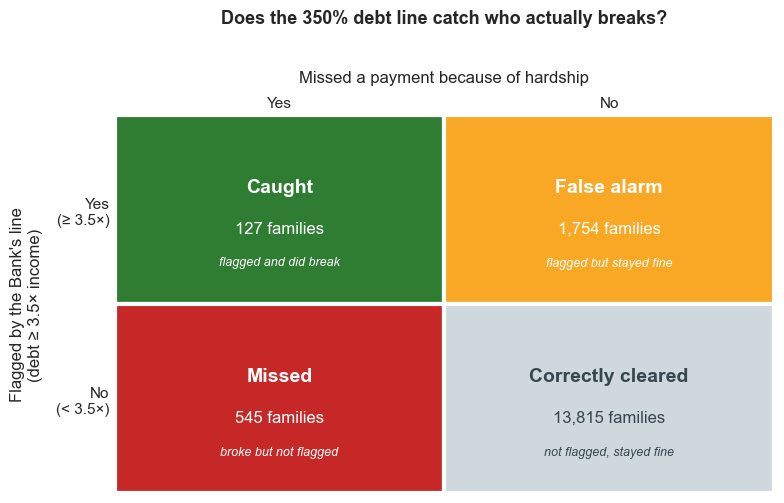

In [66]:
# a clearer view of the same four numbers: a screening grid, each corner labelled by what it means
ct = pd.crosstab(df.BOC_DTI, df.missed_pay_hardship).loc[[1, 0], [1, 2]]   # rows flagged-first, cols broke-first
counts   = ct.values
roles    = np.array([["Caught", "False alarm"], ["Missed", "Correctly cleared"]])
subtitle = np.array([["flagged and did break", "flagged but stayed fine"],
                     ["broke but not flagged", "not flagged, stayed fine"]])
colors   = np.array([["#2e7d32", "#f9a825"], ["#c62828", "#cfd8dc"]])   # caught/false-alarm ; missed/cleared

fig, ax = plt.subplots(figsize=(8, 5.2))
for r in range(2):
    for c in range(2):
        ax.add_patch(plt.Rectangle((c, 1 - r), 1, 1, facecolor=colors[r, c], edgecolor="white", lw=3))
        tc = "#37474f" if colors[r, c] == "#cfd8dc" else "white"
        ax.text(c + 0.5, 1 - r + 0.62, roles[r, c],              ha="center", va="center", color=tc, fontsize=14, fontweight="bold")
        ax.text(c + 0.5, 1 - r + 0.40, f"{counts[r, c]:,} families", ha="center", va="center", color=tc, fontsize=12)
        ax.text(c + 0.5, 1 - r + 0.22, subtitle[r, c],           ha="center", va="center", color=tc, fontsize=9, style="italic")

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(["Yes", "No"], fontsize=11)
ax.set_yticks([1.5, 0.5]); ax.set_yticklabels(["Yes\n(≥ 3.5×)", "No\n(< 3.5×)"], fontsize=11)
ax.set_xlabel("Missed a payment because of hardship", fontsize=12, labelpad=10)
ax.set_ylabel("Flagged by the Bank's line\n(debt ≥ 3.5× income)", fontsize=12, labelpad=10)
ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
ax.set_title("Does the 350% debt line catch who actually breaks?", fontsize=13, fontweight="bold", pad=34)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

In [67]:
# where the E.2 numbers come from - computed, not hand-copied
# 1) is being flagged linked to a higher chance of missing a payment?
rate_flagged   = df.loc[df.BOC_DTI == 1, "missed_pay_hardship"].eq(1).mean()
rate_unflagged = df.loc[df.BOC_DTI == 0, "missed_pay_hardship"].eq(1).mean()
print(f"Hardship rate, flagged families:   {rate_flagged:.1%}")
print(f"Hardship rate, everyone else:      {rate_unflagged:.1%}")

# 2) of the families who actually broke, how many did the line miss?
broke = df[df.missed_pay_hardship == 1]
print(f"Families who missed a payment:       {len(broke):,}")
print(f"  ...missed by the line (unflagged): {(broke.BOC_DTI == 0).mean():.0%}")

# 3) who does the 3.5 line actually flag? (reconciling with Section 3's debt finding)
flagged = df[df.BOC_DTI == 1]
print()
print(f"Median net worth, flagged families:   ${flagged.net_worth.median():,.0f}")
print(f"Median net worth, families who broke: ${broke.net_worth.median():,.0f}")
print(f"Median net worth, all families:       ${df.net_worth.median():,.0f}")
print(f"Mortgage as a share of flagged debt (median): {(flagged.debt_mortgage / flagged.debt_total).median():.0%}")

Hardship rate, flagged families:   6.8%
Hardship rate, everyone else:      3.8%
Families who missed a payment:       672
  ...missed by the line (unflagged): 81%

Median net worth, flagged families:   $1,023,505
Median net worth, families who broke: $221,312
Median net worth, all families:       $904,705
Mortgage as a share of flagged debt (median): 79%


**Reading the result.** With the target coded 1 = missed a payment through hardship and 2 = did not, the grid and the printout above answer two questions.

- **The line does pick up real risk.** Flagged families miss payments at **6.8%**, against **3.8%** for everyone else - nearly double. Sitting above the Bank's 3.5 line roughly doubles the rate of missing a payment.
- **But it misses most of the families who actually break.** Of the **672** families who missed a payment, only **127** were flagged; the line missed the other **545, about 81%**. Four out of five families who genuinely broke were carrying total debt below 3.5 times income.

That second number looks, at first, like it contradicts Section 3, where debt was the strongest driver of vulnerability. It doesn't - the two are measuring different debt. The 350% line runs on *total* debt, and for flagged families that debt is about **79% mortgage**, so the line mostly flags big-mortgage homeowners: their median net worth is over **a million dollars**, above the unflagged median, with home equity sitting behind the loan. Those are the families the models read as *safe* - which is why they break at only 6.8%. The families who actually break look the opposite: total debt only modestly above their income, but thin net worth (median **~\$221K** against **~\$905K** across all families) and the credit-card debt Section 3 singled out. So debt still drives vulnerability - the 350% line just measures the wrong slice of it, catching mortgages instead of the credit-card-and-no-cushion families who break.

<a id="ep-3"></a>
## E.3 How Canada-wide is this?

Last, the population check: what share of families land above the 3.5 line, weighted by the survey weight so the number reflects the country and not just the sample? The Bank puts about 11% of Canadian households above the line. Landing near that, allowing for the after-tax-versus-gross gap from E.1, is a sign this sample mirrors the national picture; landing far off would say the opposite.

In [68]:
weighted_share = (df[df.BOC_DTI == 1].weight.sum())/(df.weight.sum())
print(f"Weighted share of families above the 3.5 line: {weighted_share:.1%}")

Weighted share of families above the 3.5 line: 13.4%


**Reading the result.** Weighted to the country, **13.4%** of Canadian families sit above the Bank's 3.5 line. Two things stand out. First, weighting nudged the share up from the unweighted 11.6%: the highly-indebted families carry a little more survey weight than average, so they stand for a slightly larger slice of the country than of the raw sample. Second, against the Bank's own ~11%, landing at 13.4% is close - a couple of points high, in exactly the direction E.1 flagged, since the after-tax denominator lifts every family's ratio. That closeness is the real result: even after switching the income base, this sample's highly-indebted share sits within a couple of points of the national benchmark, so it mirrors the country rather than drifting from it.

## In closing

This Epilogue set out to test the models' central finding against the benchmark the institutions in this space actually use. Three steps got there: flagging the families the Bank would call highly indebted (E.1), checking whether that line catches the ones who actually miss payments (E.2), and confirming the flagged share holds up when weighted to the country (E.3).

The verdict is that the models' debt finding holds, with a twist. The Bank's 350% line is a genuine risk signal - families above it break at nearly twice the rate of everyone else - but on its own it is a coarse net: it misses about four in five families who actually miss a payment, because it reads total debt (mostly mortgage) and so flags asset-rich homeowners rather than the credit-card-burdened, thin-cushion families who break. Debt still drives vulnerability, as Section 3 found - the benchmark just watches the wrong slice of it. And the sample earns some trust along the way: weighted to the country, its highly-indebted share (13.4%) lands within a couple of points of the Bank's own figure.

So the curiosity that opened this Epilogue closes on a practical note - a single debt ratio is a useful screen, but finding the vulnerable families this project set out to identify takes the whole balance sheet, which is exactly what the models used.

<a id="references"></a>
# References

**Dataset**

Statistics Canada. (2024). *Survey of Financial Security (SFS), 2023* [Public Use Microdata File]. Catalogue no. 13M0006X. Released October 29, 2024. Used under the Statistics Canada Open Licence.

https://www150.statcan.gc.ca/n1/en/catalogue/13M0006X

**Debt-to-income benchmark**

Bank of Canada. (2019). *Financial System Review 2019*, May 2019. The threshold defining a highly indebted household as one with a debt-to-income ratio above 350 percent (about 11 percent of Canadian households), and the finding that this group holds roughly two-fifths of outstanding household debt, are drawn from Box 1.

https://www.bankofcanada.ca/2019/05/financial-system-review-2019/

**Survey methodology**

Statistics Canada. Survey of Financial Security (SFS), survey program and methodology (record 2620).

https://www.statcan.gc.ca/en/survey/household/2620

<a id="appendix"></a>
# Appendix - full data dictionary
The complete reference also lives in the repo as **`SFS 2023 - Data Dictionary.md`**.

**Important:** codes are **column-specific**, e.g. `6` means "valid skip" in `retired`, but "retirement pension" in `income_main_source`, and is just an ID number in `family_id`. Always read a code against its own column.

### Dollar columns (real amounts in CAD, no category codes)
`income_after_tax`, `income_market`, `assets_total`, `net_worth`, `debt_total`, `debt_mortgage`, `debt_credit_card`, `debt_student_loan`, `debt_line_of_credit`, `debt_vehicle`, `debt_other`.
Amounts can be negative for income and net worth. **Exception:** `income_market` uses `99,999,999` = _not stated_, treat as missing (790 rows).

### Coded columns
- **`income_main_source`**: 1 No income, 2 Wages & salaries, 3 Self-employment, 4 Government transfers, 5 Investment income, 6 Retirement pensions, 7 Other income
- **`income_expected_change`**: 1 Increase, 2 Decrease, 3 Same
- **`age_group`**: 1 Under 25, 2 25-34, 3 35-44, 4 45-54, 5 55-64, 6 65-79, 7 80+
- **`education`**: 1 < high school, 2 High school, 3 Non-university post-secondary, 4 University degree, 9 Not stated. _Refined:_ 9 -> NaN -> filled with the weighted median (`3`).
- **`gender`**: 1 Male, 2 Female
- **`visible_minority`**: 1 Yes, 2 No, 9 Not stated. _Kept as-is:_ 9 is treated as the "unknown / not stated" category (not converted).
- **`retired`**: 1 Yes, 2 No, 6 Valid skip (under 45 / never worked), 9 Not stated. _Refined:_ 6 folded into 2; 9 -> NaN -> filled with the weighted mode (`2`).
- **`missed_pay_nonmortgage`**: 1 Yes, 2 No
- **`missed_pay_hardship`**: 1 Yes, 2 No, 6 Valid skip (didn't miss a non-mortgage payment). _Refined to binary:_ 1 = hardship skip, 2 = did not. **This column is the project's target** - the definition of "financially vulnerable" (see [1.9.7](#s1-9-7)).
- **`missed_pay_mortgage`**: 1 Yes, 2 No, 6 Valid skip (no mortgage). _Refined to binary:_ 1 = skipped, 2 = did not skip / no mortgage.

### Engineered columns (Section 3 and the Epilogue)
- **`debt_to_income`** = `debt_total` / `income_after_tax` - how many years of income it would take to clear the family's debt (built and cleaned in [3.1](#s3-1)). Edge cases: 13 no-debt, no-income families (0 / 0) filled with their true value of 0; the column capped at its 99th percentile (15.91), which also sweeps in the 7 infinite values (debt / zero income); 25 negative ratios (debt / negative income) pushed up to the same cap. Final range: 0 to 15.91.
- **`BOC_DTI`** = 1 if `debt_to_income` is at or above 3.5 (the Bank of Canada's highly-indebted line), else 0 - built in [E.1](#ep-1) for the Epilogue's benchmark test.

### Cleaning summary (what was done)
- **Valid skip (`6`) -> recoded to a meaningful "No" (`2`):** `missed_pay_mortgage`, `missed_pay_hardship`, `retired`.
- **Not stated (`9`) -> `NaN`, then imputed:** `education` (weighted median = 3), `retired` (weighted mode = 2).
- **Not stated (`9`) -> kept as its own "unknown" category:** `visible_minority` (left as `9`).
- **Dollar sentinel (`99,999,999`) -> `NaN`, then imputed:** `income_market` (weighted median).

### Modeling prep summary (Section 3)
- **Target (y):** `missed_pay_hardship` recoded 1/2 -> 1/0, vulnerable = 1 (672 vs 15,569) - built as its own variable, the column itself untouched ([3.2.1](#s3-2-1)).
- **Features (X):** everything except the target, the two leakage flags (`missed_pay_nonmortgage`, `missed_pay_mortgage`), and the metadata columns (`family_id`, `weight`) - then `assets_total` dropped for its 0.98 correlation with `net_worth` ([3.2.2](#s3-2-2)). Final count: 18 features, including `debt_to_income`.
- **Preprocessing:** the five nominal columns one-hot encoded, everything numeric (ordinals included) scaled to 0-1 - defined in [3.3](#s3-3), fitted on training data only in [3.4](#s3-4).